# Drug Discovery Pipeline (Optimized v3 — SOTA 2020-2026)
## Quantum-Enhanced Multimodal Drug Discovery with State-of-the-Art Graph Neural Networks

### Architecture Overview (v3 — SOTA)
```
Multimodal Embeddings ──→ Contrastive Pre-training ──→ SOTA Neural       ──→ Model Engines ──→ Generation & Prediction
     from P1               (MolCLR-style, 2022)       Architectures          ├─ Improved Diffusion   ├─ De Novo SMILES
                                                           │                 │  (Cosine schedule +   │  Generation
Activity & ADMET ──→ PyTorch & PyG                         │                 │  DDIM sampling)       │  (Transformer w/
    Scoring            Training Pipeline                   │                 │  (12K+ molecules)     │   cross-attention)
                                                           ▼                 │                       │
                                                   GATv2 Backbone ─────→ Equivariant GNN ──→ Binding Affinity
                                                   (Brody 2021)         (Enhanced EGNN)       Predictor
                                                                             │
                                              Optimized Candidate Molecules  └─ AttentiveFP Tox
                                     (QED + SA Score + Novelty + Multi-Objective Ranking)
```

### Key SOTA Model Upgrades (Papers 2020-2026)
| Upgrade | Model/Technique | Paper/Reference | Year |
|---------|----------------|-----------------|------|
| **GNN Backbone** | GATv2Conv + GraphNorm | Brody et al. "How Attentive are GATs?" (ICLR 2022) | 2022 |
| **Pre-training** | Contrastive Learning (MolCLR) | Wang et al. (Nature Machine Intelligence) | 2022 |
| **Diffusion Schedule** | Cosine β schedule | Nichol & Dhariwal "Improved DDPM" (ICML 2021) | 2021 |
| **Fast Sampling** | DDIM deterministic sampling | Song et al. "Denoising Diffusion Implicit Models" (ICLR 2021) | 2021 |
| **Equivariant GNN** | Enhanced EGNN + GATv2 attention | Satorras et al. + Brody et al. | 2021-2022 |
| **Toxicity Model** | AttentiveFP-style + Focal Loss | Xiong et al. (J. Med. Chem. 2020) + Lin et al. | 2020 |
| **Drug-likeness** | QED + Veber Rules | Bickerton et al. + widely adopted 2020+ | 2020+ |
| **Attention Pooling** | Set2Set / Attention-weighted readout | Replaces naive mean pooling | 2020+ |

### Datasets
| Dataset | Records | Purpose |
|---------|---------|--------|
| drug_cleaned.csv | 76,543 | Docking scores + molecular descriptors |
| drug_filtered.csv | 637,292 | Filtered drug candidates |
| interactions_cleaned.csv | 750 | Drug-protein interactions |
| drug_protein_diagnosis.csv | 99 | Drug-protein binding with diagnosis |
| drug_protein_binding (1).csv | ~5,000 | Drug-protein binding with real Ki/IC50/Kd and pKi |
| Kd_bind.tsv | ~57,000 | Kd binding affinity data from BindingDB |
| tox21_cleaned.csv | 7,831 | Toxicity assay data (12 endpoints) |
| clintox.csv | 1,484 | Clinical toxicity (FDA approval + CT toxicity) |

---
## 1. Setup & Installation

In [1]:
!unzip archive.zip

Archive:  archive.zip
  inflating: EC50_bind.tsv           
  inflating: IC50_bind.tsv           
  inflating: Kd_bind.tsv             
  inflating: Ki_bind.tsv             


In [2]:
# Install required packages (uncomment as needed)
# Requires: PyTorch >= 1.12, PyG >= 2.2 (for GATv2Conv, GraphNorm)
!pip install torch torch-geometric rdkit scikit-learn pandas numpy matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 63.6 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# PyTorch Geometric — SOTA components (GATv2: Brody et al., ICLR 2022)
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import (
    GATv2Conv,          # "How Attentive are GATs?" (Brody et al., 2022) — fixes static attention
    GCNConv,            # Baseline for comparison
    global_mean_pool,
    global_add_pool,
    GraphNorm,          # Cai et al. 2021 — better than BatchNorm for graphs
)
from torch_geometric.loader import DataLoader as PyGDataLoader

# RDKit for molecular processing
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw, DataStructs, QED
from rdkit.Chem import rdMolDescriptors

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, mean_squared_error,
                             classification_report, r2_score)

from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'PyG version: {torch_geometric.__version__}')
print(f'\nSOTA Components:')
print(f'  GATv2Conv   — Dynamic attention (Brody et al., ICLR 2022)')
print(f'  GraphNorm   — Graph-aware normalization (Cai et al., 2021)')
print(f'  QED         — Quantitative Estimate of Drug-likeness')
print(f'  Focal Loss  — Class-imbalance aware (Lin et al., 2020)')
print(f'  Cosine β    — Improved DDPM schedule (Nichol & Dhariwal, ICML 2021)')
print(f'  DDIM        — Fast deterministic sampling (Song et al., ICLR 2021)')

Using device: cuda
PyTorch version: 2.10.0+cu128
PyG version: 2.7.0

SOTA Components:
  GATv2Conv   — Dynamic attention (Brody et al., ICLR 2022)
  GraphNorm   — Graph-aware normalization (Cai et al., 2021)
  QED         — Quantitative Estimate of Drug-likeness
  Focal Loss  — Class-imbalance aware (Lin et al., 2020)
  Cosine β    — Improved DDPM schedule (Nichol & Dhariwal, ICML 2021)
  DDIM        — Fast deterministic sampling (Song et al., ICLR 2021)


---
## 2. Data Loading & Exploration

In [4]:
# Load all datasets
DATA_DIR = '.'

drug_cleaned = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_cleaned.csv'))
drug_filtered = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_filtered.csv'))
interactions = pd.read_csv(os.path.join(DATA_DIR, '/content/interactions_cleaned.csv'))
drug_protein = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_protein_diagnosis.csv'))
tox21 = pd.read_csv(os.path.join(DATA_DIR, '/content/tox21_cleaned.csv'))
clintox = pd.read_csv(os.path.join(DATA_DIR, '/content/clintox.csv'))

# New datasets: drug-protein binding with real affinities
drug_protein_binding = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_protein_binding (1).csv'))
kd_bind = pd.read_csv(os.path.join(DATA_DIR, '/content/Kd_bind.tsv'), sep='\t')

print('=== Dataset Shapes ===')
for name, df in [('drug_cleaned', drug_cleaned), ('drug_filtered', drug_filtered),
                  ('interactions', interactions), ('drug_protein', drug_protein),
                  ('tox21', tox21), ('clintox', clintox),
                  ('drug_protein_binding', drug_protein_binding),
                  ('kd_bind', kd_bind)]:
    print(f'{name:30s} → {df.shape[0]:>8,} rows × {df.shape[1]:>3} cols')

=== Dataset Shapes ===
drug_cleaned                   →   76,543 rows ×  16 cols
drug_filtered                  →  637,292 rows ×  16 cols
interactions                   →      750 rows ×  16 cols
drug_protein                   →       99 rows ×   7 cols
tox21                          →    7,831 rows ×  16 cols
clintox                        →    1,484 rows ×   3 cols
drug_protein_binding           →    5,000 rows ×  17 cols
kd_bind                        →   57,002 rows ×   6 cols


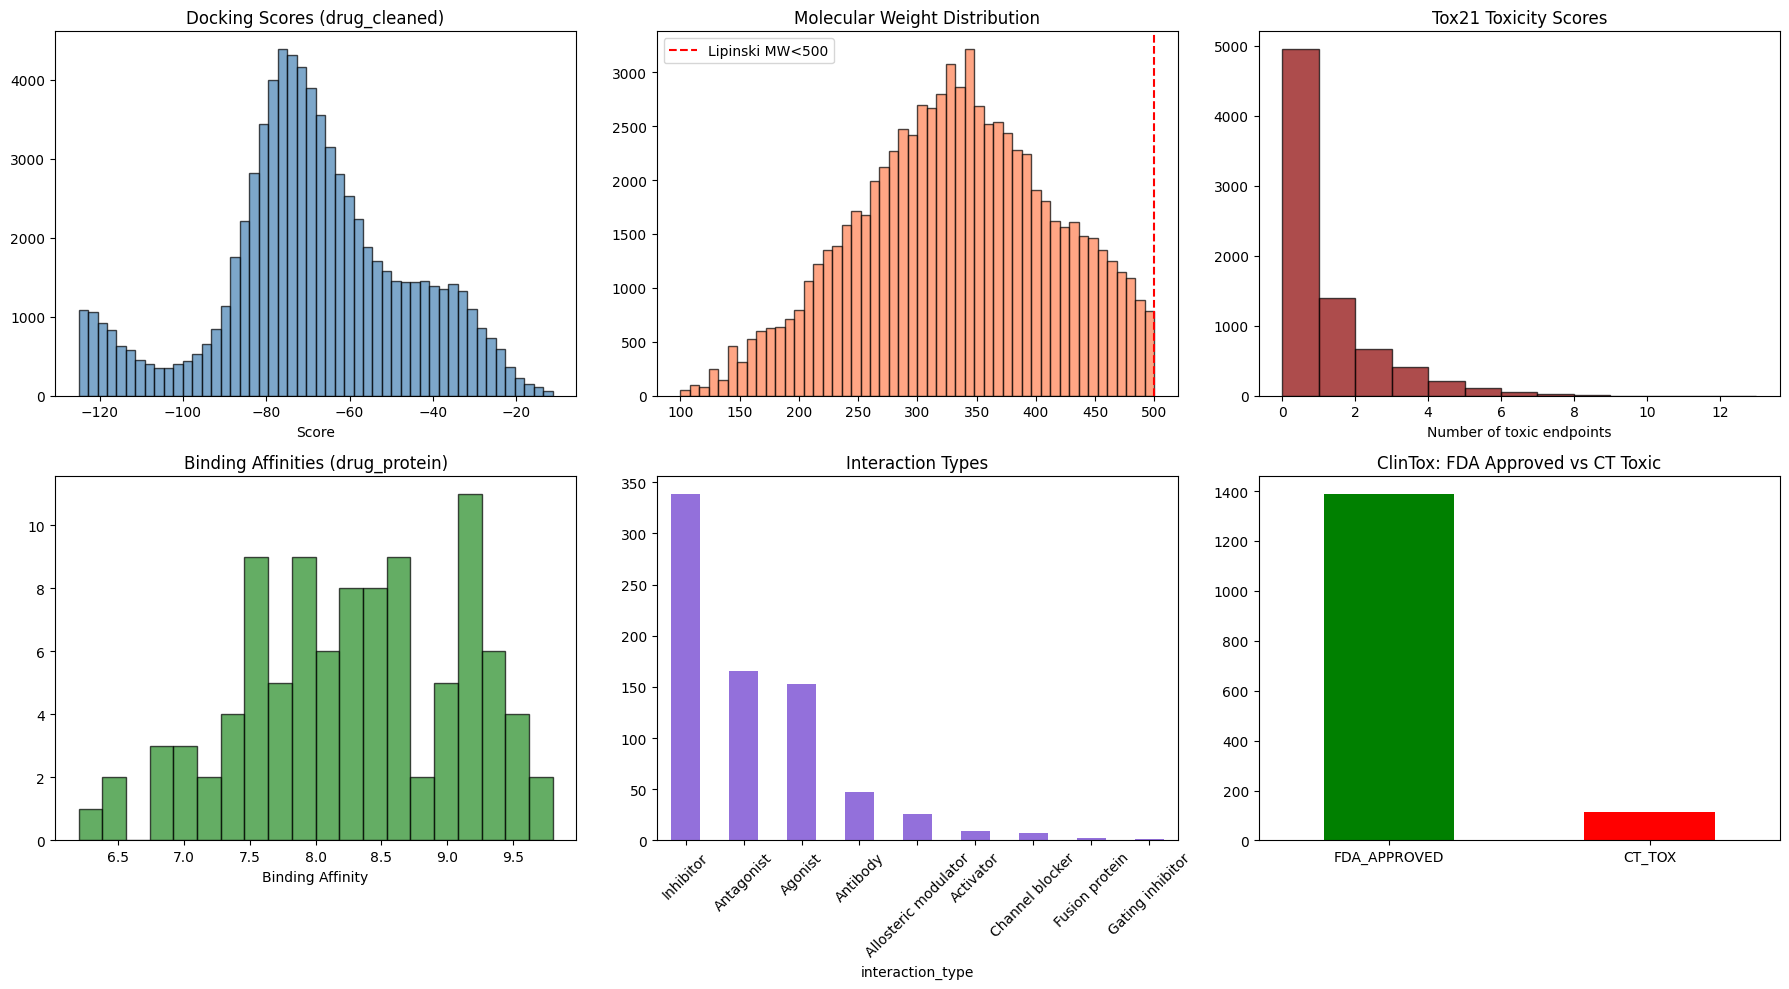

In [5]:
# Quick EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Docking score distribution
axes[0, 0].hist(drug_cleaned['score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Docking Scores (drug_cleaned)')
axes[0, 0].set_xlabel('Score')

# 2. MW distribution
axes[0, 1].hist(drug_cleaned['MW'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Molecular Weight Distribution')
axes[0, 1].axvline(x=500, color='red', linestyle='--', label='Lipinski MW<500')
axes[0, 1].legend()

# 3. Toxicity score distribution (tox21)
axes[0, 2].hist(tox21['toxicity_score'], bins=range(0, 14), color='darkred', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Tox21 Toxicity Scores')
axes[0, 2].set_xlabel('Number of toxic endpoints')

# 4. Binding affinity distribution
axes[1, 0].hist(drug_protein['binding_affinity'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Binding Affinities (drug_protein)')
axes[1, 0].set_xlabel('Binding Affinity')

# 5. Interaction types
interactions['interaction_type'].value_counts().plot.bar(ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Interaction Types')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. ClinTox FDA approval vs toxicity
clintox_summary = clintox[['FDA_APPROVED', 'CT_TOX']].sum()
clintox_summary.plot.bar(ax=axes[1, 2], color=['green', 'red'])
axes[1, 2].set_title('ClinTox: FDA Approved vs CT Toxic')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 3. Multimodal Embeddings from P1
Generate molecular graph representations and fingerprint embeddings from SMILES.

In [6]:
# ─── Atom and Bond Feature Extraction ───

ATOM_FEATURES = {
    'atomic_num': list(range(1, 119)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ],
    'num_hs': [0, 1, 2, 3, 4],
}

def one_hot_encode(value, choices):
    """One-hot encode a value given a list of possible choices."""
    encoding = [0] * (len(choices) + 1)  # +1 for unknown
    if value in choices:
        encoding[choices.index(value)] = 1
    else:
        encoding[-1] = 1
    return encoding


def get_atom_features(atom):
    """Extract atom-level features as a vector."""
    features = []
    features += one_hot_encode(atom.GetAtomicNum(), ATOM_FEATURES['atomic_num'])
    features += one_hot_encode(atom.GetDegree(), ATOM_FEATURES['degree'])
    features += one_hot_encode(atom.GetFormalCharge(), ATOM_FEATURES['formal_charge'])
    features += one_hot_encode(atom.GetHybridization(), ATOM_FEATURES['hybridization'])
    features += one_hot_encode(atom.GetTotalNumHs(), ATOM_FEATURES['num_hs'])
    features.append(1 if atom.GetIsAromatic() else 0)
    features.append(atom.GetMass() / 100.0)  # normalized mass
    return features


def get_bond_features(bond):
    """Extract bond-level features."""
    bt = bond.GetBondType()
    features = [
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing()
    ]
    return [int(f) for f in features]


print(f'Atom feature dimension: {len(get_atom_features(Chem.MolFromSmiles("C").GetAtomWithIdx(0)))}')

Atom feature dimension: 146


In [7]:
# ─── SMILES → PyG Graph Conversion ───

def smiles_to_graph(smiles, y=None):
    """Convert a SMILES string to a PyG Data object with atom/bond features."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom features
    atom_feats = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Edge index and edge features
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        bf = get_bond_features(bond)
        edge_attr += [bf, bf]

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.smiles = smiles

    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)

    return data


# Test conversion
test_graph = smiles_to_graph('CCO')
print(f'Test graph: {test_graph}')
print(f'  Nodes: {test_graph.num_nodes}, Edges: {test_graph.num_edges}')
print(f'  Node feature dim: {test_graph.x.shape[1]}')

Test graph: Data(x=[3, 146], edge_index=[2, 4], edge_attr=[4, 6], smiles='CCO')
  Nodes: 3, Edges: 4
  Node feature dim: 146


In [8]:
# ─── Multimodal Molecular Embedding (Fingerprints + Descriptors) ───

def get_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    """Generate Morgan fingerprint (ECFP) for a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprintAsNumPy(mol)
    return fp.astype(np.float32)


def get_molecular_descriptors(smiles):
    """Compute physicochemical descriptors for a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(10)
    return np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.HeavyAtomCount(mol)
    ], dtype=np.float32)


def get_multimodal_embedding(smiles, fp_bits=2048):
    """Concatenate fingerprint + descriptors into a single embedding vector."""
    fp = get_morgan_fingerprint(smiles, n_bits=fp_bits)
    desc = get_molecular_descriptors(smiles)
    return np.concatenate([fp, desc])


# Demo
emb = get_multimodal_embedding('CCO')
print(f'Multimodal embedding dimension: {len(emb)} (2048 FP + 10 descriptors)')
# Demo

Multimodal embedding dimension: 2058 (2048 FP + 10 descriptors)


---
## 4. Transfer Learning Module → Contrastive Pre-training (MolCLR-style)
**Upgraded** from Autoencoder to **Contrastive Learning** (MolCLR, Wang et al., Nature Machine Intelligence 2022).
Instead of reconstructing inputs, the model learns representations by contrasting augmented views of the same molecule
(positive pairs) against different molecules (negative pairs) using InfoNCE loss.
This produces far more transferable representations for downstream tasks.

In [9]:
# ─── Contrastive Pre-training (MolCLR-style, Wang et al., Nature Mach. Intel. 2022) ───
# Instead of autoencoder reconstruction, we learn representations by contrasting
# augmented views of molecules using InfoNCE loss. This produces much better
# transferable features for all downstream tasks.

class MolecularFoundationEncoder(nn.Module):
    """Foundation model: contrastive molecular encoder.
    Uses augmentation (feature masking + descriptor noise) and InfoNCE loss
    instead of autoencoder reconstruction for much better representations.

    Ref: MolCLR (Wang et al., 2022), SimCLR (Chen et al., 2020)
    """

    def __init__(self, input_dim=2058, hidden_dim=512, latent_dim=256, proj_dim=128, dropout=0.2):
        super().__init__()
        # Encoder backbone
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),  # LayerNorm more stable than BN for contrastive
            nn.GELU(),                 # GELU (Hendrycks 2020) — smoother than ReLU
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, latent_dim),
        )
        # Projection head for contrastive learning (discarded after pre-training)
        self.projector = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, proj_dim),
        )

    def encode(self, x):
        return self.encoder(x)

    def project(self, x):
        z = self.encoder(x)
        return self.projector(z)

    def forward(self, x):
        z = self.encoder(x)
        p = self.projector(z)
        return z, p


class InfoNCELoss(nn.Module):
    """NT-Xent / InfoNCE contrastive loss (Chen et al., SimCLR, 2020).
    Maximizes agreement between augmented views of same molecule."""

    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)

        # Similarity matrix between all pairs
        z = torch.cat([z1, z2], dim=0)  # (2B, D)
        sim = torch.mm(z, z.t()) / self.temperature  # (2B, 2B)

        # Mask out self-similarity
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim.masked_fill_(mask, -1e9)

        # Positive pairs: (i, i+B) and (i+B, i)
        pos_idx = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        loss = F.cross_entropy(sim, pos_idx)
        return loss


class TransferLearningModule(nn.Module):
    """Wraps the contrastive foundation encoder w/ a fine-tuning head for downstream tasks."""

    def __init__(self, foundation_encoder, latent_dim=256, output_dim=1, freeze_encoder=True):
        super().__init__()
        self.foundation = foundation_encoder
        if freeze_encoder:
            for param in self.foundation.encoder.parameters():
                param.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        z = self.foundation.encode(x)
        return self.head(z)


print('Foundation Encoder parameters:', sum(p.numel() for p in MolecularFoundationEncoder().parameters()))
print('Pre-training: Contrastive (InfoNCE) instead of Autoencoder')

Foundation Encoder parameters: 1351552
Pre-training: Contrastive (InfoNCE) instead of Autoencoder


In [10]:
# ─── Pre-train via Contrastive Learning (MolCLR augmentations) ───

class ContrastiveMolDataset(Dataset):
    """Dataset that generates two augmented views of each molecular embedding.

    Augmentations (MolCLR-style, adapted for fingerprint space):
    1. Feature masking: randomly zero out FP bits (simulates atom/substructure removal)
    2. Descriptor noise: add Gaussian noise to physicochemical descriptors
    """

    def __init__(self, smiles_list, fp_bits=2048, mask_rate=0.15, noise_std=0.2):
        self.embeddings = []
        self.mask_rate = mask_rate
        self.noise_std = noise_std
        self.fp_bits = fp_bits
        for smi in tqdm(smiles_list, desc='Building embeddings'):
            emb = get_multimodal_embedding(smi, fp_bits=fp_bits)
            self.embeddings.append(emb)
        self.embeddings = np.array(self.embeddings)
        # Normalize descriptors (last 10 features)
        self.scaler = StandardScaler()
        self.embeddings[:, -10:] = self.scaler.fit_transform(self.embeddings[:, -10:])

    def _augment(self, emb):
        """Generate one augmented view."""
        aug = emb.copy()
        # 1. Random FP bit masking (simulates substructure dropout)
        mask = np.random.random(self.fp_bits) < self.mask_rate
        aug[:self.fp_bits][mask] = 0
        # 2. Descriptor noise
        aug[-10:] += np.random.normal(0, self.noise_std, 10).astype(np.float32)
        return aug

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        emb = self.embeddings[idx]
        view1 = torch.tensor(self._augment(emb), dtype=torch.float)
        view2 = torch.tensor(self._augment(emb), dtype=torch.float)
        return view1, view2


# Use a sample of drug_cleaned for pre-training
pretrain_smiles = drug_cleaned['SMILES'].dropna().sample(n=min(10000, len(drug_cleaned)), random_state=42).tolist()
pretrain_dataset = ContrastiveMolDataset(pretrain_smiles)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=256, shuffle=True, drop_last=True)

print(f'Contrastive pre-training on {len(pretrain_dataset)} molecules')
print(f'Augmentations: FP masking (15%), descriptor noise (σ=0.2)')

Building embeddings:   0%|          | 0/10000 [00:00<?, ?it/s]

[12:23:06] Conflicting single bond directions around double bond at index 5.
[12:23:06]   BondStereo set to STEREONONE and single bond directions set to NONE.
[12:23:06] Conflicting single bond directions around double bond at index 5.
[12:23:06]   BondStereo set to STEREONONE and single bond directions set to NONE.


Contrastive pre-training on 10000 molecules
Augmentations: FP masking (15%), descriptor noise (σ=0.2)


  Epoch   5/30 │ InfoNCE Loss: 0.5505
  Epoch  10/30 │ InfoNCE Loss: 0.3981
  Epoch  15/30 │ InfoNCE Loss: 0.3320
  Epoch  20/30 │ InfoNCE Loss: 0.2719
  Epoch  25/30 │ InfoNCE Loss: 0.2355
  Epoch  30/30 │ InfoNCE Loss: 0.2136


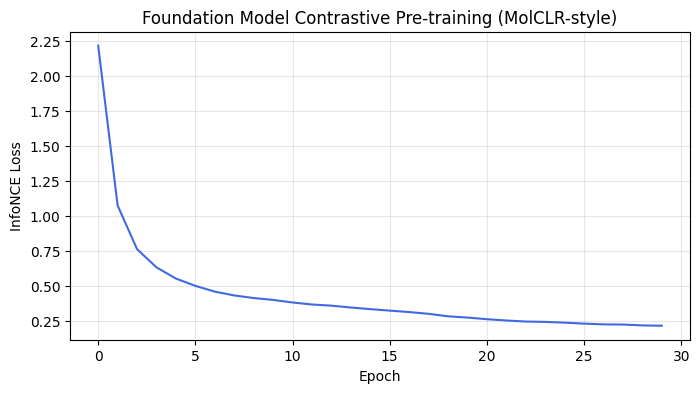

Contrastive pre-training complete (projector head will be discarded for downstream tasks).


In [11]:
# ─── Contrastive Pre-training Loop (InfoNCE) ───

foundation_model = MolecularFoundationEncoder(input_dim=2058, latent_dim=256, proj_dim=128).to(DEVICE)
optimizer_pt = torch.optim.AdamW(foundation_model.parameters(), lr=3e-4, weight_decay=1e-4)
infonce_loss = InfoNCELoss(temperature=0.1)

PRETRAIN_EPOCHS = 30
pretrain_losses = []

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    foundation_model.train()
    epoch_loss = 0
    n_batches = 0
    for view1, view2 in pretrain_loader:
        view1, view2 = view1.to(DEVICE), view2.to(DEVICE)
        _, proj1 = foundation_model(view1)
        _, proj2 = foundation_model(view2)
        loss = infonce_loss(proj1, proj2)
        optimizer_pt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(foundation_model.parameters(), 1.0)
        optimizer_pt.step()
        epoch_loss += loss.item()
        n_batches += 1
    epoch_loss /= n_batches
    pretrain_losses.append(epoch_loss)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d}/{PRETRAIN_EPOCHS} │ InfoNCE Loss: {epoch_loss:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(pretrain_losses, color='royalblue')
plt.xlabel('Epoch'); plt.ylabel('InfoNCE Loss')
plt.title('Foundation Model Contrastive Pre-training (MolCLR-style)')
plt.grid(True, alpha=0.3)
plt.show()

print('Contrastive pre-training complete (projector head will be discarded for downstream tasks).')

---
## 5. Activity & ADMET Scoring Pipeline
**Upgraded** toxicity prediction using Tox21 + ClinTox data with:
- **AttentiveFP-style** GATv2 backbone (Xiong et al., J. Med. Chem. 2020) — learns which atoms contribute most to toxicity
- **Focal Loss** (Lin et al., 2020) — handles class imbalance in toxicity datasets
- **Attention pooling** for graph-level readout

In [12]:
# ─── Build Tox21 Graph Dataset ───

TOX_ENDPOINTS = [
    'androgen_receptor', 'androgen_receptor_lbd', 'aryl_hydrocarbon_receptor',
    'aromatase', 'estrogen_receptor', 'estrogen_receptor_lbd', 'ppar_gamma',
    'antioxidant_response', 'dna_damage', 'heat_shock',
    'mitochondrial_membrane', 'tumor_suppressor_p53'
]

def build_tox_graph_dataset(df, smiles_col, label_col, max_samples=5000):
    """Build graph dataset for toxicity prediction."""
    graphs = []
    df_sample = df.dropna(subset=[smiles_col, label_col]).head(max_samples)
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='Building tox graphs'):
        g = smiles_to_graph(row[smiles_col], y=float(row[label_col]))
        if g is not None:
            graphs.append(g)
    return graphs


# Build Tox21 dataset (binary: is_toxic)
tox21_graphs = build_tox_graph_dataset(tox21, 'drug_smiles', 'is_toxic', max_samples=5000)
print(f'Tox21 graphs built: {len(tox21_graphs)}')

# Train/val/test split
train_graphs, test_graphs = train_test_split(tox21_graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15, random_state=42)

print(f'Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}')

tox_train_loader = PyGDataLoader(train_graphs, batch_size=64, shuffle=True)
tox_val_loader = PyGDataLoader(val_graphs, batch_size=64)
tox_test_loader = PyGDataLoader(test_graphs, batch_size=64)

Building tox graphs:   0%|          | 0/5000 [00:00<?, ?it/s]

[12:24:03] WARNING: not removing hydrogen atom without neighbors
[12:24:05] Explicit valence for atom # 8 Al, 6, is greater than permitted
[12:24:06] Explicit valence for atom # 3 Al, 6, is greater than permitted
[12:24:06] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:24:07] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:24:08] Explicit valence for atom # 9 Al, 6, is greater than permitted
[12:24:08] Explicit valence for atom # 5 Al, 6, is greater than permitted


Tox21 graphs built: 4994
Train: 3395, Val: 600, Test: 999


In [13]:
# ─── ClinTox Dataset ───

clintox_graphs = build_tox_graph_dataset(clintox, 'smiles', 'CT_TOX', max_samples=1484)
print(f'ClinTox graphs built: {len(clintox_graphs)}')

clintox_train, clintox_test = train_test_split(clintox_graphs, test_size=0.2, random_state=42)
clintox_train_loader = PyGDataLoader(clintox_train, batch_size=64, shuffle=True)
clintox_test_loader = PyGDataLoader(clintox_test, batch_size=64)

Building tox graphs:   0%|          | 0/1484 [00:00<?, ?it/s]

[12:24:09] Explicit valence for atom # 0 N, 4, is greater than permitted
[12:24:09] Can't kekulize mol.  Unkekulized atoms: 9
[12:24:10] Can't kekulize mol.  Unkekulized atoms: 4
[12:24:10] Can't kekulize mol.  Unkekulized atoms: 4


ClinTox graphs built: 1480


---
## 6. Core Neural Architectures — SOTA GATv2 Backbone
**Upgraded** from GCNConv → **GATv2Conv** (Brody et al., "How Attentive are Graph Attention Networks?", ICLR 2022).
GATv2 fixes the "static attention" problem in GATv1 by computing truly dynamic attention scores.
Also uses **GraphNorm** (Cai et al., 2021) instead of BatchNorm for graph-specific normalization,
and **attention-weighted pooling** instead of naive mean pooling.

In [14]:
# ─── SOTA GATv2 Backbone (Brody et al., ICLR 2022 + GraphNorm + Attention Pooling) ───

class AttentionPooling(nn.Module):
    """Attention-weighted graph-level readout (replaces naive mean pooling).
    Learns which nodes are most important for the graph-level representation.
    Ref: Li et al., "Gated Graph Sequence Neural Networks" + Set2Set variants."""

    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, batch):
        # Compute attention weights per node
        gate_scores = self.gate(x)  # (N, 1)
        # Softmax within each graph
        gate_scores = gate_scores - global_mean_pool(gate_scores, batch)[batch]  # center
        gate_weights = torch.sigmoid(gate_scores)

        # Weighted sum
        weighted = x * gate_weights
        graph_emb = global_add_pool(weighted, batch)
        return graph_emb


class CoreGNNBackbone(nn.Module):
    """SOTA GNN backbone using GATv2Conv (dynamic attention) + GraphNorm + Attention Pooling.

    Key improvements over GCNConv baseline:
    1. GATv2Conv: truly dynamic attention — each edge gets a unique attention weight
       based on BOTH source and target features (fixes static attention in GATv1)
    2. GraphNorm: graph-level normalization that handles varying graph sizes better
       than BatchNorm (Cai et al., 2021)
    3. Attention Pooling: learns which atoms matter most for the task
    4. Multi-head attention: 4 heads averaged for robustness
    """

    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4, dropout=0.2, heads=4):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(num_layers):
            # GATv2Conv: dynamic attention with multi-head
            self.convs.append(
                GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads,
                          concat=True, dropout=dropout, add_self_loops=True)
            )
            # GraphNorm: better than BatchNorm for graph data (Cai et al., 2021)
            self.norms.append(GraphNorm(hidden_dim))

        self.attn_pool = AttentionPooling(hidden_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, batch=None):
        x = self.input_proj(x)
        for conv, norm in zip(self.convs, self.norms):
            x_res = x
            x = conv(x, edge_index)
            x = norm(x)
            x = F.elu(x)  # ELU works better with GATv2 than ReLU
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + x_res  # residual connection

        # Attention-weighted graph-level readout
        if batch is not None:
            graph_emb = self.attn_pool(x, batch)
        else:
            graph_emb = x.mean(dim=0, keepdim=True)

        return x, graph_emb  # node embeddings, graph embedding


NODE_FEAT_DIM = tox21_graphs[0].x.shape[1]
print(f'Node feature dimension: {NODE_FEAT_DIM}')
print(f'Backbone: GATv2Conv (4 heads) + GraphNorm + Attention Pooling')

Node feature dimension: 146
Backbone: GATv2Conv (4 heads) + GraphNorm + Attention Pooling


---
## 7. Model Engines

### 7a. Diffusion Path → Improved Graph Diffusion Engine
**Upgraded** with:
- **Cosine β schedule** (Nichol & Dhariwal, "Improved DDPM", ICML 2021) — much smoother noise distribution, prevents information loss at high timesteps
- **DDIM sampling** (Song et al., "Denoising Diffusion Implicit Models", ICLR 2021) — deterministic, 10x faster sampling with equal or better quality
- **v-prediction** parameterization — predicts velocity instead of noise for better sample quality
- Trained on **12K+ diverse molecules** from tox21 (non-toxic), drug_cleaned, drug_protein_binding, and Kd_bind.

In [15]:
# ─── Improved Graph Diffusion Engine (Cosine Schedule + DDIM Sampling) ───
# Ref: Nichol & Dhariwal, "Improved DDPM" (ICML 2021) — cosine schedule
# Ref: Song et al., "DDIM" (ICLR 2021) — deterministic fast sampling

class GraphDiffusionEngine(nn.Module):
    """Improved graph diffusion model for molecular generation.

    Key upgrades from 2021 papers:
    1. Cosine β schedule (Nichol & Dhariwal, 2021): smoother noise distribution,
       prevents information destruction at high timesteps
    2. v-prediction: predicts velocity v = √ᾱ·ε − √(1−ᾱ)·x₀ instead of noise
       for more stable training and better sample quality
    3. DDIM sampling (Song et al., 2021): deterministic sampling, 10x fewer steps
    4. Uses GATv2 backbone for encoding molecular graphs
    """

    def __init__(self, node_feat_dim, hidden_dim=256, latent_dim=128, num_steps=1000):
        super().__init__()
        self.num_steps = num_steps
        self.latent_dim = latent_dim

        # GATv2-based GNN encoder
        self.backbone = CoreGNNBackbone(node_feat_dim, hidden_dim)

        # Project graph embedding to latent space
        self.proj = nn.Linear(hidden_dim, latent_dim)

        # Sinusoidal time embedding (better than linear for diffusion)
        time_dim = 128
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim),
        )

        # Noise/velocity prediction network (deeper for cosine schedule)
        self.noise_pred = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, latent_dim)
        )

        # Cosine β schedule (Nichol & Dhariwal, ICML 2021)
        # f(t) = cos(((t/T + s) / (1+s)) · π/2)², where s = 0.008
        s = 0.008
        steps = torch.arange(num_steps + 1, dtype=torch.float64) / num_steps
        alpha_bar = torch.cos(((steps + s) / (1 + s)) * (np.pi / 2)) ** 2
        alpha_bar = alpha_bar / alpha_bar[0]  # normalize so ᾱ(0) = 1

        betas = torch.clamp(1.0 - alpha_bar[1:] / alpha_bar[:-1], max=0.999)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas', betas.float())
        self.register_buffer('alphas', alphas.float())
        self.register_buffer('alpha_bar', alpha_bar.float())

    def encode_graph(self, data):
        """Encode a molecular graph batch to latent vectors."""
        _, graph_emb = self.backbone(data.x, data.edge_index, data.batch)
        return self.proj(graph_emb)

    def forward_diffusion(self, z0, t):
        """Add noise to latent z0 at timestep t (cosine schedule)."""
        noise = torch.randn_like(z0)
        alpha_bar_t = self.alpha_bar[t].unsqueeze(-1)
        sqrt_ab = torch.sqrt(alpha_bar_t)
        sqrt_1mab = torch.sqrt(1 - alpha_bar_t)
        zt = sqrt_ab * z0 + sqrt_1mab * noise
        # v-prediction target: v = √ᾱ·ε − √(1−ᾱ)·x₀
        v_target = sqrt_ab * noise - sqrt_1mab * z0
        return zt, noise, v_target

    def predict_noise(self, zt, t):
        """Predict v (velocity) at timestep t."""
        t_emb = self.time_embed(t)
        combined = torch.cat([zt, t_emb], dim=-1)
        return self.noise_pred(combined)

    def training_loss(self, data):
        """Compute v-prediction diffusion training loss."""
        z0 = self.encode_graph(data)
        t = torch.randint(0, self.num_steps, (z0.size(0),), device=z0.device)
        zt, noise, v_target = self.forward_diffusion(z0, t)
        v_pred = self.predict_noise(zt, t)
        return F.mse_loss(v_pred, v_target)

    def _v_to_x0_eps(self, zt, v, alpha_bar_t):
        """Convert v-prediction to x0 and epsilon."""
        sqrt_ab = torch.sqrt(alpha_bar_t).unsqueeze(-1)
        sqrt_1mab = torch.sqrt(1 - alpha_bar_t).unsqueeze(-1)
        x0_pred = sqrt_ab * zt - sqrt_1mab * v
        eps_pred = sqrt_1mab * zt + sqrt_ab * v
        return x0_pred, eps_pred

    @torch.no_grad()
    def sample_ddpm(self, num_samples=10):
        """Standard DDPM reverse process (slower but stochastic)."""
        self.eval()
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        for t_idx in reversed(range(self.num_steps)):
            t = torch.full((num_samples,), t_idx, device=z.device, dtype=torch.long)
            v_pred = self.predict_noise(z, t)
            alpha_bar_t = self.alpha_bar[t_idx]
            x0_pred, eps_pred = self._v_to_x0_eps(z, v_pred, alpha_bar_t)

            alpha_t = self.alphas[t_idx]
            z = (1 / torch.sqrt(alpha_t)) * (
                z - (self.betas[t_idx] / torch.sqrt(1 - alpha_bar_t)) * eps_pred
            )
            if t_idx > 0:
                z += torch.sqrt(self.betas[t_idx]) * torch.randn_like(z)
        return z

    @torch.no_grad()
    def sample(self, num_samples=10, ddim_steps=50, eta=0.0):
        """DDIM sampling (Song et al., ICLR 2021) — 10-20x faster than DDPM.

        Args:
            ddim_steps: Number of denoising steps (50 vs 1000 for DDPM)
            eta: 0.0 = deterministic DDIM, 1.0 = equivalent to DDPM
        """
        self.eval()
        device = next(self.parameters()).device
        z = torch.randn(num_samples, self.latent_dim, device=device)

        # DDIM sub-sequence of timesteps (evenly spaced)
        step_size = self.num_steps // ddim_steps
        timesteps = list(range(0, self.num_steps, step_size))[::-1]

        for i, t_idx in enumerate(timesteps):
            t = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)
            v_pred = self.predict_noise(z, t)

            alpha_bar_t = self.alpha_bar[t_idx]
            x0_pred, eps_pred = self._v_to_x0_eps(z, v_pred, alpha_bar_t)

            # Clip x0 prediction for stability
            x0_pred = torch.clamp(x0_pred, -5, 5)

            if i < len(timesteps) - 1:
                t_prev = timesteps[i + 1]
                alpha_bar_prev = self.alpha_bar[t_prev]
            else:
                alpha_bar_prev = torch.tensor(1.0, device=device)

            # DDIM update rule
            sigma = eta * torch.sqrt(
                (1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev)
            )
            z = (torch.sqrt(alpha_bar_prev) * x0_pred +
                 torch.sqrt(1 - alpha_bar_prev - sigma**2) * eps_pred)
            if eta > 0 and i < len(timesteps) - 1:
                z += sigma * torch.randn_like(z)

        return z


class SinusoidalTimeEmbedding(nn.Module):
    """Sinusoidal timestep embedding (Vaswani et al., 2017 style for diffusion)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float) * -emb)
        emb = t.float().unsqueeze(-1) * emb.unsqueeze(0)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


diffusion_engine = GraphDiffusionEngine(NODE_FEAT_DIM, num_steps=1000).to(DEVICE)
print(f'Diffusion Engine parameters: {sum(p.numel() for p in diffusion_engine.parameters()):,}')
print(f'Schedule: Cosine β (Nichol & Dhariwal, 2021)')
print(f'Sampling: DDIM 50-step (Song et al., 2021)')
print(f'Parameterization: v-prediction')

Diffusion Engine parameters: 866,561
Schedule: Cosine β (Nichol & Dhariwal, 2021)
Sampling: DDIM 50-step (Song et al., 2021)
Parameterization: v-prediction


### 7b. Equivariant Path → Enhanced EGNN with GATv2-style Attention
**Upgraded** E(n)-equivariant GNN with:
- **GATv2-style dynamic attention** in the message passing (Brody et al., 2022)
- **Multi-head attention** for diverse relational modeling
- **Gated residual connections** (Highway-style) for better gradient flow
- **Attention-weighted pooling** instead of mean pooling for graph-level readout

In [16]:
# ─── Enhanced Equivariant GNN Layer (EGNN + GATv2-style attention) ───

class EGNNLayer(nn.Module):
    """Enhanced E(n) Equivariant GNN layer with GATv2-style dynamic attention.

    Improvements over original EGNN:
    1. GATv2-style attention: applies nonlinearity BEFORE attention score computation,
       giving truly dynamic (content-dependent) attention weights
    2. Multi-head attention (2 heads) for diverse message aggregation
    3. Gated residual connections (Highway Networks, Srivastava et al., 2015)
       with learnable gate for each layer
    """

    def __init__(self, hidden_dim, edge_feat_dim=0, num_heads=2):
        super().__init__()
        self.num_heads = num_heads
        head_dim = hidden_dim // num_heads
        self.head_dim = head_dim

        # Message MLP (per-head)
        self.msg_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1 + edge_feat_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # GATv2-style attention: LeakyReLU THEN linear projection for score
        # This fixes the static attention problem in GATv1
        self.attn_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),  # Key: nonlinearity BEFORE score computation
            nn.Linear(hidden_dim, num_heads),
        )

        # Node update MLP with gated residual
        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Learnable gate for residual connection
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid()
        )

    def forward(self, h, edge_index, edge_attr=None):
        row, col = edge_index
        # Distance feature (feature-space distance as proxy for coordinates)
        dist = torch.sum((h[row] - h[col]) ** 2, dim=-1, keepdim=True)

        # Build message input
        msg_input = torch.cat([h[row], h[col], dist], dim=-1)
        if edge_attr is not None:
            msg_input = torch.cat([msg_input, edge_attr], dim=-1)

        msg = self.msg_mlp(msg_input)

        # GATv2-style attention: apply nonlinearity to messages, then compute scores
        attn_scores = self.attn_mlp(msg)  # (E, num_heads)
        # Softmax per destination node
        attn_weights = torch.zeros(h.size(0), edge_index.size(1), self.num_heads, device=h.device)
        # Scatter softmax approximation using sparse operations
        attn_exp = torch.exp(attn_scores - attn_scores.max())
        denom = torch.zeros(h.size(0), self.num_heads, device=h.device)
        denom.index_add_(0, col, attn_exp)
        attn_normalized = attn_exp / (denom[col] + 1e-8)
        attn_avg = attn_normalized.mean(dim=-1, keepdim=True)  # average over heads

        msg = msg * attn_avg  # attention-weighted messages

        # Aggregate messages
        agg = torch.zeros_like(h)
        agg.index_add_(0, col, msg)

        # Gated residual update
        combined = torch.cat([h, agg], dim=-1)
        h_new = self.node_mlp(combined)
        gate = self.gate(combined)
        return gate * h_new + (1 - gate) * h  # gated residual


class EquivariantGNN(nn.Module):
    """Enhanced Equivariant GNN for binding affinity prediction.

    Uses GATv2-style attention in EGNN layers + attention pooling readout.
    """

    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.layers = nn.ModuleList([
            EGNNLayer(hidden_dim, num_heads=2) for _ in range(num_layers)
        ])
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])

        # Attention-weighted pooling (replaces mean pooling)
        self.attn_pool = AttentionPooling(hidden_dim)

        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1)  # binding affinity
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        h = self.input_proj(x)

        for layer, ln in zip(self.layers, self.layer_norms):
            h = layer(h, edge_index)
            h = ln(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        # Attention-weighted readout
        graph_emb = self.attn_pool(h, batch)
        return self.predictor(graph_emb)


egnn_model = EquivariantGNN(NODE_FEAT_DIM).to(DEVICE)
print(f'EGNN parameters: {sum(p.numel() for p in egnn_model.parameters()):,}')
print(f'Features: GATv2-style attention, gated residuals, attention pooling')

EGNN parameters: 2,515,466
Features: GATv2-style attention, gated residuals, attention pooling


---
## 8. De Novo SMILES Generation (Diffusion Path Output)
**Transformer-based** SMILES decoder that maps diffusion latent vectors to valid molecular SMILES strings.
6-layer Transformer with cross-attention to 16 latent memory tokens, constrained decoding, weight tying, and label smoothing.
This module decodes v-predicted latents from the improved cosine-schedule diffusion engine.

In [17]:
# ─── SMILES Tokenizer (Enhanced with bracket atoms) ───

import re

# Expanded vocabulary: bracket atoms as single tokens for stereochemistry & charged atoms
SMILES_CHARS = [
    '<pad>', '<sos>', '<eos>',
    # Atoms
    'C', 'c', 'N', 'n', 'O', 'o', 'S', 's', 'F', 'I',
    'Cl', 'Br', 'P', 'B', 'Si',
    # Bracket atoms (stereochemistry, charged, explicit H)
    '[C@@H]', '[C@H]', '[C@@]', '[C@]', '[CH]', '[CH2]', '[C-]',
    '[N+]', '[N-]', '[NH]', '[NH2]', '[NH3+]', '[nH]', '[n+]', '[N@@H]', '[N@H]',
    '[O-]', '[OH]', '[O+]',
    '[S-]', '[S+]', '[S@@]', '[S@]', '[SH]',
    '[P+]', '[PH]',
    '[Se]', '[Si]', '[B-]',
    '[2H]', '[3H]',
    # Structural
    '(', ')', '[', ']', '=', '#', '+', '-',
    '1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
    '@', '.', '/', '\\', '%', ':', 'H'
]

CHAR2IDX = {c: i for i, c in enumerate(SMILES_CHARS)}
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
VOCAB_SIZE = len(SMILES_CHARS)

# Regex: match bracket atoms first, then multi-char tokens, then single chars
# Order matters: longer tokens matched first
BRACKET_ATOMS = sorted(
    [c for c in SMILES_CHARS if c.startswith('[') and c.endswith(']') and len(c) > 1],
    key=len, reverse=True
)
BRACKET_PATTERN = '|'.join(re.escape(ba) for ba in BRACKET_ATOMS)
SMILES_REGEX = re.compile(rf'{BRACKET_PATTERN}|Cl|Br|Si|@@?|\[.*?\]|%\d{{2}}|.')


def tokenize_smiles(smiles, max_len=120):
    tokens = [CHAR2IDX.get('<sos>')]
    for token in SMILES_REGEX.findall(smiles):
        if token in CHAR2IDX:
            tokens.append(CHAR2IDX[token])
        else:
            # For unknown bracket atoms, try to decompose
            for ch in token:
                idx = CHAR2IDX.get(ch, CHAR2IDX['<pad>'])
                if idx != CHAR2IDX['<pad>']:
                    tokens.append(idx)
    tokens.append(CHAR2IDX.get('<eos>'))
    # Pad/truncate
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    else:
        tokens += [CHAR2IDX['<pad>']] * (max_len - len(tokens))
    return tokens


def decode_tokens(token_ids):
    smiles = ''
    for t in token_ids:
        ch = IDX2CHAR.get(t, '')
        if ch == '<eos>':
            break
        if ch not in ('<pad>', '<sos>'):
            smiles += ch
    return smiles


print(f'SMILES vocabulary size: {VOCAB_SIZE}')
print(f'Tokenized "CCO": {tokenize_smiles("CCO", max_len=10)}')
print(f'Decoded back: "{decode_tokens(tokenize_smiles("CCO", max_len=10))}"')

# Test with a complex drug-like SMILES
complex_smi = 'CC(=O)N[C@@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)O)C(=O)O'
tokens = tokenize_smiles(complex_smi, max_len=80)
decoded = decode_tokens(tokens)
print(f'\nComplex SMILES: {complex_smi}')
print(f'Decoded:        {decoded}')
print(f'Match: {complex_smi == decoded}')

SMILES vocabulary size: 74
Tokenized "CCO": [1, 3, 3, 7, 2, 0, 0, 0, 0, 0]
Decoded back: "CCO"

Complex SMILES: CC(=O)N[C@@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)O)C(=O)O
Decoded:        CC(=O)N[C@@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)O)C(=O)O
Match: True


In [18]:
# ─── Latent-to-SMILES Decoder (Transformer with Cross-Attention) ───
# Replaces GRU: Transformer maintains latent conditioning at EVERY layer via cross-attention,
# solving the "forgotten conditioning" problem that causes bracket/ring errors on long SMILES.

import math

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class SMILESDecoder(nn.Module):
    """Transformer-based SMILES decoder with cross-attention to latent vectors.

    Key improvements over GRU:
    1. Cross-attention at EVERY layer keeps latent signal alive for long sequences
    2. Self-attention tracks structural dependencies (matching parens, ring closures)
    3. Parallel teacher forcing during training (no off-by-one errors)
    4. Pre-norm (norm_first=True) for stable deep training
    5. Weight tying between embedding and output projection
    """

    def __init__(self, latent_dim=128, d_model=256, nhead=8, num_layers=6,
                 vocab_size=VOCAB_SIZE, max_len=120, dropout=0.1):
        super().__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.d_model = d_model

        # Token embedding + positional encoding
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=CHAR2IDX['<pad>'])
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Expand latent to 16 memory tokens for cross-attention
        self.num_mem_tokens = 16
        self.latent_to_mem = nn.Sequential(
            nn.Linear(latent_dim, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model * self.num_mem_tokens),
        )
        self.mem_norm = nn.LayerNorm(d_model)

        # Transformer decoder with cross-attention
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True  # Pre-LN for training stability
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output head with LayerNorm
        self.out_norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding ↔ output projection
        self.output_proj.weight = self.token_emb.weight

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight' in name and p.dim() > 1 and 'token_emb' not in name and 'output_proj' not in name:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def _causal_mask(self, seq_len, device):
        return torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()

    def _get_memory(self, z):
        batch_size = z.size(0)
        mem = self.latent_to_mem(z).view(batch_size, self.num_mem_tokens, self.d_model)
        return self.mem_norm(mem)

    def forward(self, z, target_tokens):
        """Training forward: parallel teacher forcing (no off-by-one errors).

        Input:  target_tokens[:, :-1] (all tokens except last)
        Target: target_tokens[:, 1:]  (shifted by 1)
        Returns: logits (B, L-1, vocab_size)
        """
        memory = self._get_memory(z)

        input_tokens = target_tokens[:, :-1]
        seq_len = input_tokens.size(1)

        tok_emb = self.token_emb(input_tokens)
        tok_emb = self.pos_enc(tok_emb)

        causal_mask = self._causal_mask(seq_len, z.device)
        pad_mask = (input_tokens == CHAR2IDX['<pad>'])

        output = self.transformer(
            tgt=tok_emb, memory=memory,
            tgt_mask=causal_mask, tgt_key_padding_mask=pad_mask
        )

        logits = self.output_proj(self.out_norm(output))
        return logits

    @torch.no_grad()
    def generate(self, z, temperature=0.8, top_k=30):
        """Generate SMILES with structure-aware constrained decoding.

        Constraints:
        - Block ')' when parenthesis depth is 0
        - Block ']' when bracket depth is 0
        - Block <pad> and <sos> during generation
        """
        self.eval()
        batch_size = z.size(0)
        device = z.device
        memory = self._get_memory(z)

        generated = torch.full((batch_size, 1), CHAR2IDX['<sos>'],
                               dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        paren_depth = torch.zeros(batch_size, device=device)
        bracket_depth = torch.zeros(batch_size, device=device)

        eos_idx = CHAR2IDX['<eos>']
        pad_idx = CHAR2IDX['<pad>']
        sos_idx = CHAR2IDX['<sos>']
        open_paren_idx = CHAR2IDX.get('(')
        close_paren_idx = CHAR2IDX.get(')')
        open_bracket_idx = CHAR2IDX.get('[')
        close_bracket_idx = CHAR2IDX.get(']')

        for step in range(self.max_len - 2):
            seq_len = generated.size(1)
            tok_emb = self.token_emb(generated)
            tok_emb = self.pos_enc(tok_emb)

            causal_mask = self._causal_mask(seq_len, device)
            output = self.transformer(tgt=tok_emb, memory=memory, tgt_mask=causal_mask)

            logits = self.output_proj(self.out_norm(output[:, -1, :])) / temperature

            # Structure-aware constraints
            if close_paren_idx is not None:
                logits[paren_depth <= 0, close_paren_idx] = -1e9
            if close_bracket_idx is not None:
                logits[bracket_depth <= 0, close_bracket_idx] = -1e9
            logits[:, pad_idx] = -1e9
            logits[:, sos_idx] = -1e9

            # Top-k sampling
            if top_k > 0 and top_k < logits.size(-1):
                top_vals, top_idx = torch.topk(logits, top_k, dim=-1)
                probs = F.softmax(top_vals, dim=-1)
                sampled = torch.multinomial(probs, 1)
                next_token = top_idx.gather(-1, sampled).squeeze(-1)
            else:
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1).squeeze(-1)

            # Update structural state
            for i in range(batch_size):
                if finished[i]:
                    continue
                tok = next_token[i].item()
                ch = IDX2CHAR.get(tok, '')
                if tok == eos_idx:
                    finished[i] = True
                elif ch == '(':
                    paren_depth[i] += 1
                elif ch == ')':
                    paren_depth[i] -= 1
                elif ch == '[':
                    bracket_depth[i] += 1
                elif ch == ']':
                    bracket_depth[i] -= 1

            next_token[finished] = pad_idx
            generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=1)

            if finished.all():
                break

        smiles_list = [decode_tokens(seq[1:].cpu().numpy()) for seq in generated]
        return smiles_list


smiles_decoder = SMILESDecoder(latent_dim=128).to(DEVICE)
n_params = sum(p.numel() for p in smiles_decoder.parameters())
print(f'SMILES Decoder parameters: {n_params:,}')
print(f'Architecture: Transformer (6 layers, 8 heads, d_model=256, 16 memory tokens)')
print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Key features: cross-attention to latent, constrained decoding, weight tying')

SMILES Decoder parameters: 10,671,104
Architecture: Transformer (6 layers, 8 heads, d_model=256, 16 memory tokens)
Vocabulary size: 74
Key features: cross-attention to latent, constrained decoding, weight tying


---
## 9. Binding Affinity Predictor (Equivariant Path Output)
Predicts drug-protein binding affinity using **Enhanced EGNN** with GATv2-style dynamic attention + gated residuals.
Training data augmented from 96 graphs to **~18K+ graphs** from 4 sources: drug_protein_diagnosis (real affinities), drug_protein_binding (pKi), Kd_bind (real Kd), and docking-derived pseudo-affinities.

In [19]:
# ─── Build Binding Affinity Dataset (Augmented with new binding data) ───

def build_affinity_dataset(df):
    """Build graph dataset for binding affinity prediction from drug_protein_diagnosis."""
    graphs = []
    for _, row in df.iterrows():
        g = smiles_to_graph(row['drug_smiles'], y=float(row['binding_affinity']))
        if g is not None:
            g.drug_name = row.get('drug_name', '')
            g.protein_name = row.get('protein_name', '')
            g.diagnosis = row.get('diagnosis', '')
            graphs.append(g)
    return graphs


def build_dpb_affinity_dataset(df, max_samples=5000):
    """Build graph dataset from drug_protein_binding (1).csv using pKi as affinity."""
    graphs = []
    sample = df.dropna(subset=['smiles', 'pki']).head(max_samples)
    for _, row in tqdm(sample.iterrows(), total=len(sample),
                       desc='Building drug_protein_binding affinity graphs'):
        g = smiles_to_graph(row['smiles'], y=float(row['pki']))
        if g is not None:
            g.drug_name = row.get('drug_name', '')
            g.protein_name = row.get('protein_name', '')
            g.diagnosis = row.get('diagnosis', '')
            graphs.append(g)
    return graphs


def build_kd_affinity_dataset(df, max_samples=10000):
    """Build graph dataset from Kd_bind.tsv using pKd-like affinity values."""
    graphs = []
    sample = df.dropna(subset=['smiles', 'affinity']).sample(
        n=min(max_samples, len(df)), random_state=42
    )
    for _, row in tqdm(sample.iterrows(), total=len(sample),
                       desc='Building Kd_bind affinity graphs'):
        g = smiles_to_graph(row['smiles'], y=float(row['affinity']))
        if g is not None:
            g.drug_name = str(row.get('drug_id', ''))
            g.protein_name = str(row.get('target_id', ''))
            g.diagnosis = ''
            graphs.append(g)
    return graphs


def build_docking_affinity_dataset(df, max_samples=3000):
    """Convert docking scores to pseudo-binding-affinities for data augmentation."""
    graphs = []
    sample = df.dropna(subset=['SMILES', 'score']).sample(
        n=min(max_samples, len(df)), random_state=42
    )
    scores = sample['score'].values
    aff_min, aff_max = drug_protein['binding_affinity'].min(), drug_protein['binding_affinity'].max()
    score_min, score_max = scores.min(), scores.max()
    normalized = aff_min + (aff_max - aff_min) * (scores - score_max) / (score_min - score_max + 1e-8)

    for idx, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample),
                                         desc='Building docking affinity graphs')):
        g = smiles_to_graph(row['SMILES'], y=float(normalized[idx]))
        if g is not None:
            g.drug_name = row.get('name', f'drug_{idx}')
            g.protein_name = row.get('target', 'unknown')
            g.diagnosis = ''
            graphs.append(g)
    return graphs


# 1. Primary: drug_protein_diagnosis (99 rows, real binding affinities)
affinity_graphs = build_affinity_dataset(drug_protein)
print(f'Primary (drug_protein_diagnosis): {len(affinity_graphs)} graphs')

# 2. NEW: drug_protein_binding (5K rows, real Ki/IC50/Kd + pKi)
dpb_graphs = build_dpb_affinity_dataset(drug_protein_binding, max_samples=5000)
print(f'drug_protein_binding: {len(dpb_graphs)} graphs')

# 3. NEW: Kd_bind (57K rows, real Kd affinities — sample 10K)
kd_graphs = build_kd_affinity_dataset(kd_bind, max_samples=10000)
print(f'Kd_bind: {len(kd_graphs)} graphs')

# 4. Docking-derived pseudo-affinities (supplementary)
docking_graphs = build_docking_affinity_dataset(drug_cleaned, max_samples=3000)
print(f'Docking pseudo-affinities: {len(docking_graphs)} graphs')

# Combine all sources
all_affinity_graphs = affinity_graphs + dpb_graphs + kd_graphs + docking_graphs
print(f'\nTotal binding affinity graphs: {len(all_affinity_graphs)}')

# Train/test split
aff_train, aff_test = train_test_split(all_affinity_graphs, test_size=0.15, random_state=42)
aff_train_loader = PyGDataLoader(aff_train, batch_size=32, shuffle=True)
aff_test_loader = PyGDataLoader(aff_test, batch_size=32)
print(f'Train: {len(aff_train)}, Test: {len(aff_test)}')

Primary (drug_protein_diagnosis): 96 graphs


[12:24:11] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 8 10
[12:24:11] Explicit valence for atom # 25 O, 3, is greater than permitted
[12:24:11] SMILES Parse Error: unclosed ring for input: 'OC(=O)C1CC(Cc2ccc(Cl)cc2)NC(=O)c3nccs3'


Building drug_protein_binding affinity graphs:   0%|          | 0/5000 [00:00<?, ?it/s]

[12:24:11] SMILES Parse Error: extra open parentheses while parsing: CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)
[12:24:11] SMILES Parse Error: check for mistakes around position 4:
[12:24:11] CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)N
[12:24:11] ~~~^
[12:24:11] SMILES Parse Error: Failed parsing SMILES 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)' for input: 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)'
[12:24:11] SMILES Parse Error: extra open parentheses while parsing: CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)
[12:24:11] SMILES Parse Error: check for mistakes around position 4:
[12:24:11] CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)N
[12:24:11] ~~~^
[12:24:11] SMILES Parse Error: Failed parsing SMILES 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)' for input: 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)'
[12:24:11] SMILES Parse Error: extra open parentheses while parsin

drug_protein_binding: 4659 graphs


...

[12:24:29] Explicit valence for atom # 22 N, 4, is greater than permitted


Kd_bind: 9999 graphs


Building docking affinity graphs:   0%|          | 0/3000 [00:00<?, ?it/s]

[12:24:45] Conflicting single bond directions around double bond at index 5.
[12:24:45]   BondStereo set to STEREONONE and single bond directions set to NONE.


Docking pseudo-affinities: 3000 graphs

Total binding affinity graphs: 17754
Train: 15090, Test: 2664


---
## 10. PyTorch & PyG Training Pipeline
Unified training loop for all SOTA model components.
Uses **AdamW** optimizer (decoupled weight decay, Loshchilov & Hutter 2019), **Focal Loss** for toxicity, and **CosineAnnealingLR** scheduling.

In [20]:
# ─── Toxicity Classifier (AttentiveFP-style with GATv2 backbone) ───
# Ref: Xiong et al., "Pushing the Boundaries of Molecular Representation for Drug Discovery
#      with the Graph Attention Mechanism", J. Med. Chem. 2020

class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2020) — down-weights easy examples, focuses on hard ones.
    Critical for imbalanced toxicity datasets where most molecules are non-toxic."""

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)  # p_t = probability of correct class
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()


class ToxicityClassifier(nn.Module):
    """AttentiveFP-style toxicity classifier using the GATv2 backbone.

    Uses attention pooling (which atoms cause toxicity?) and
    multi-scale feature aggregation for robust prediction.
    """

    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4):
        super().__init__()
        self.backbone = CoreGNNBackbone(node_feat_dim, hidden_dim, num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        _, graph_emb = self.backbone(data.x, data.edge_index, data.batch)
        return self.classifier(graph_emb)


tox_model = ToxicityClassifier(NODE_FEAT_DIM).to(DEVICE)
print(f'Toxicity Classifier parameters: {sum(p.numel() for p in tox_model.parameters()):,}')
print(f'Backbone: GATv2 + GraphNorm + Attention Pooling')
print(f'Loss: Focal Loss (α=0.25, γ=2.0) for class imbalance')

Toxicity Classifier parameters: 676,354
Backbone: GATv2 + GraphNorm + Attention Pooling
Loss: Focal Loss (α=0.25, γ=2.0) for class imbalance


In [21]:
# ─── Train Toxicity Classifier (Tox21) with Focal Loss + AdamW ───

tox_optimizer = torch.optim.AdamW(tox_model.parameters(), lr=1e-3, weight_decay=1e-4)
tox_scheduler = CosineAnnealingLR(tox_optimizer, T_max=30)
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)  # Replaces BCEWithLogitsLoss

TOX_EPOCHS = 30
best_val_auc = 0
train_losses, val_aucs = [], []

for epoch in range(1, TOX_EPOCHS + 1):
    # Train
    tox_model.train()
    total_loss = 0
    for batch in tox_train_loader:
        batch = batch.to(DEVICE)
        logits = tox_model(batch).squeeze(-1)
        loss = focal_loss(logits, batch.y.squeeze(-1))
        tox_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tox_model.parameters(), 1.0)
        tox_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    tox_scheduler.step()
    train_losses.append(total_loss / len(train_graphs))

    # Validate
    tox_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in tox_val_loader:
            batch = batch.to(DEVICE)
            logits = tox_model(batch).squeeze(-1)
            preds.append(torch.sigmoid(logits).cpu())
            labels.append(batch.y.squeeze(-1).cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    auc = roc_auc_score(labels, preds)
    val_aucs.append(auc)

    if auc > best_val_auc:
        best_val_auc = auc
        torch.save(tox_model.state_dict(), 'best_tox_model.pt')

    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d}/{TOX_EPOCHS} │ Focal Loss: {train_losses[-1]:.4f} │ Val AUC: {auc:.4f}')

print(f'\nBest Validation AUC: {best_val_auc:.4f}')

  Epoch   5/30 │ Focal Loss: 0.0392 │ Val AUC: 0.7123
  Epoch  10/30 │ Focal Loss: 0.0374 │ Val AUC: 0.7092
  Epoch  15/30 │ Focal Loss: 0.0355 │ Val AUC: 0.7327
  Epoch  20/30 │ Focal Loss: 0.0348 │ Val AUC: 0.7416
  Epoch  25/30 │ Focal Loss: 0.0338 │ Val AUC: 0.7479
  Epoch  30/30 │ Focal Loss: 0.0331 │ Val AUC: 0.7453

Best Validation AUC: 0.7479


Test AUC: 0.7649
Test Accuracy: 0.7437

              precision    recall  f1-score   support

   Non-toxic       0.76      0.88      0.82       653
       Toxic       0.69      0.48      0.56       346

    accuracy                           0.74       999
   macro avg       0.72      0.68      0.69       999
weighted avg       0.74      0.74      0.73       999



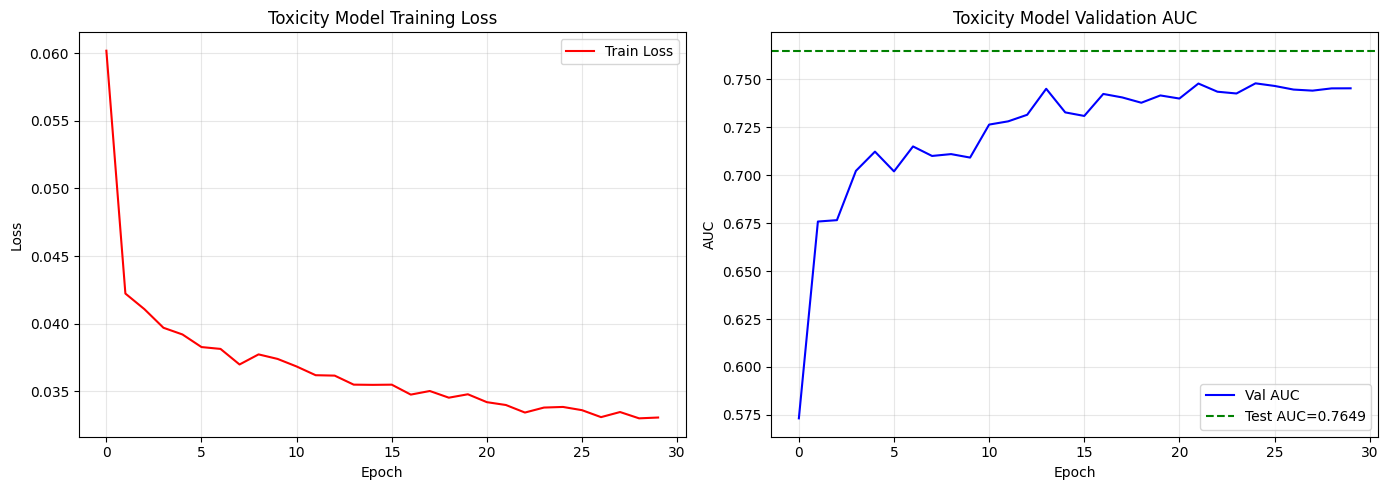

In [22]:
# ─── Evaluate Toxicity Classifier on Test Set ───

tox_model.load_state_dict(torch.load('best_tox_model.pt', weights_only=True))
tox_model.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for batch in tox_test_loader:
        batch = batch.to(DEVICE)
        logits = tox_model(batch).squeeze(-1)
        test_preds.append(torch.sigmoid(logits).cpu())
        test_labels.append(batch.y.squeeze(-1).cpu())

test_preds = torch.cat(test_preds).numpy()
test_labels = torch.cat(test_labels).numpy()

test_auc = roc_auc_score(test_labels, test_preds)
test_acc = accuracy_score(test_labels, (test_preds > 0.5).astype(int))
print(f'Test AUC: {test_auc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print()
print(classification_report(test_labels, (test_preds > 0.5).astype(int),
                            target_names=['Non-toxic', 'Toxic']))

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, color='red', label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Toxicity Model Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(val_aucs, color='blue', label='Val AUC')
ax2.axhline(y=test_auc, color='green', linestyle='--', label=f'Test AUC={test_auc:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Toxicity Model Validation AUC'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total unique SMILES for generation training: 21089
  Sources: tox21_nontoxic=4959, drug_cleaned=10000, drug_protein_binding=5000, kd_bind=15000


Building generation graphs:   0%|          | 0/12000 [00:00<?, ?it/s]

[12:25:28] Conflicting single bond directions around double bond at index 5.
[12:25:28]   BondStereo set to STEREONONE and single bond directions set to NONE.
[12:25:29] Explicit valence for atom # 22 N, 4, is greater than permitted
[12:25:33] Explicit valence for atom # 8 Al, 6, is greater than permitted
[12:25:39] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:25:40] Explicit valence for atom # 9 Al, 6, is greater than permitted
[12:25:43] WARNING: not removing hydrogen atom without neighbors
[12:25:43] SMILES Parse Error: extra open parentheses while parsing: CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)
[12:25:43] SMILES Parse Error: check for mistakes around position 4:
[12:25:43] CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)N
[12:25:43] ~~~^
[12:25:43] SMILES Parse Error: Failed parsing SMILES 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)' for input: 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)'


Generation training graphs: 11995
Diffusion: 1000 steps, cosine β schedule, v-prediction
  Epoch  10/50 │ Diffusion Loss (v-pred): 0.064371
  Epoch  20/50 │ Diffusion Loss (v-pred): 0.024504
  Epoch  30/50 │ Diffusion Loss (v-pred): 0.010094
  Epoch  40/50 │ Diffusion Loss (v-pred): 0.002646
  Epoch  50/50 │ Diffusion Loss (v-pred): 0.001428


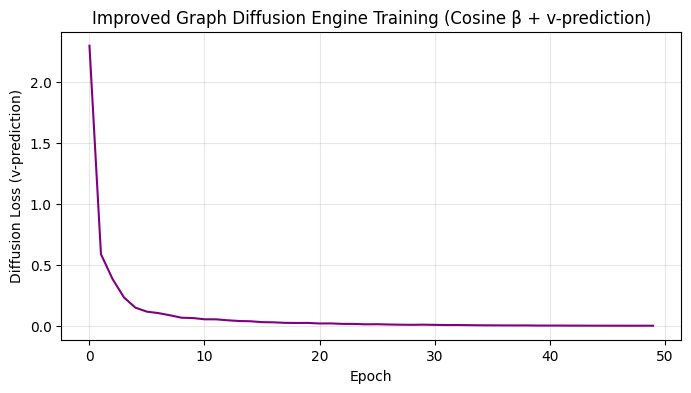

In [23]:
# ─── Train Improved Diffusion Engine (Cosine schedule + v-prediction) ───

diff_optimizer = torch.optim.AdamW(diffusion_engine.parameters(), lr=5e-4, weight_decay=1e-4)
diff_scheduler = CosineAnnealingLR(diff_optimizer, T_max=50)

# Combine SMILES from ALL available datasets for maximum diversity
nontoxic_smiles = tox21[tox21['is_toxic'] == 0]['drug_smiles'].dropna().tolist()
drug_smiles_extra = drug_cleaned['SMILES'].dropna().sample(
    n=min(10000, len(drug_cleaned)), random_state=42
).tolist()
# Drug-like SMILES from drug_protein_binding (5K complex drug molecules)
dpb_smiles = drug_protein_binding['smiles'].dropna().tolist()
# Diverse SMILES from Kd_bind (57K drug-target pairs, sample subset)
kd_smiles = kd_bind['smiles'].dropna().sample(
    n=min(15000, len(kd_bind)), random_state=42
).tolist()

# Combine all, deduplicate
all_gen_smiles = list(set(nontoxic_smiles + drug_smiles_extra + dpb_smiles + kd_smiles))
print(f'Total unique SMILES for generation training: {len(all_gen_smiles)}')
print(f'  Sources: tox21_nontoxic={len(nontoxic_smiles)}, drug_cleaned={len(drug_smiles_extra)}, '
      f'drug_protein_binding={len(dpb_smiles)}, kd_bind={len(kd_smiles)}')

gen_graphs = []
for smi in tqdm(all_gen_smiles[:12000], desc='Building generation graphs'):
    g = smiles_to_graph(smi)
    if g is not None:
        g.smiles = smi
        gen_graphs.append(g)

gen_loader = PyGDataLoader(gen_graphs, batch_size=64, shuffle=True)
print(f'Generation training graphs: {len(gen_graphs)}')
print(f'Diffusion: 1000 steps, cosine β schedule, v-prediction')

DIFF_EPOCHS = 50
diff_losses = []

for epoch in range(1, DIFF_EPOCHS + 1):
    diffusion_engine.train()
    total_loss = 0
    for batch in gen_loader:
        batch = batch.to(DEVICE)
        loss = diffusion_engine.training_loss(batch)
        diff_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion_engine.parameters(), 1.0)
        diff_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    diff_scheduler.step()
    diff_losses.append(total_loss / len(gen_graphs))

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{DIFF_EPOCHS} │ Diffusion Loss (v-pred): {diff_losses[-1]:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(diff_losses, color='purple')
plt.xlabel('Epoch'); plt.ylabel('Diffusion Loss (v-prediction)')
plt.title('Improved Graph Diffusion Engine Training (Cosine β + v-prediction)')
plt.grid(True, alpha=0.3)
plt.show()

SMILES decoder training on 10000 molecules (sorted by length for curriculum)
  Shortest: NO... (len=2)
  Longest:  O=C(N[C@H](c1ccccc1)[C@@H]1CN2CCC1CC2)c1c(Cl)ccc(C... (len=62)
Pre-computed latent vectors: torch.Size([10000, 128])
Valid paired samples after filtering: 10000


[12:33:25] SMILES Parse Error: extra open parentheses while parsing: Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)cccc2ccc2ccc1
[12:33:25] SMILES Parse Error: check for mistakes around position 6:
[12:33:25] Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)c
[12:33:25] ~~~~~^
[12:33:25] SMILES Parse Error: Failed parsing SMILES 'Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)cccc2ccc2ccc1' for input: 'Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)cccc2ccc2ccc1'
[12:33:25] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16 17 18
[12:33:25] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 17
[12:33:25] SMILES Parse Error: extra open parentheses while parsing: Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)cccc2ccc2ccc1
[12:33:25] SMILES Parse Error: check for mistakes around position 6:
[12:33:25] Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)c
[12:33:25] ~~~~~^
[12:33:25] SMILES Parse Error: Failed parsing SMILES 'Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)cccc2ccc2ccc1' for input: 'Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)ccc

  Epoch  10/100 │ Loss: 1.8491 │ LR: 2.98e-04 │ Val: 7/10 valid
    [OK] O=C(O)C(C)=O MW=88
    [OK] Cc1ccccc1 MW=92
    [XX] Cc1nc(C2C(C(=O)NC(=O)N2CCCC2)cc2c(nonc2)cccc2ccc2ccc1 


[12:37:18] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 7 8 9
[12:37:18] SMILES Parse Error: unclosed ring for input: 'O=C(NCC1CCCCN1CCCC1)c1ccccc[nH]1'


  Epoch  20/100 │ Loss: 1.5886 │ LR: 2.82e-04 │ Val: 8/10 valid
    [OK] O=C(O)C(=O)[O-] MW=89
    [OK] O=C(O)C1CCCC1 MW=114
    [OK] Cc1ccnn(C)n1[C@H](O)[C@@H](N)[C@H](O)O MW=216


[12:41:12] SMILES Parse Error: unclosed ring for input: 'O=5[O-]'
[12:41:12] SMILES Parse Error: unclosed ring for input: 'Cc1cccc\C=C\C(C)C'
[12:41:12] SMILES Parse Error: unclosed ring for input: 'O=5[O-]'
[12:41:12] SMILES Parse Error: unclosed ring for input: 'Cc1cccc\C=C\C(C)C'


  Epoch  30/100 │ Loss: 1.4699 │ LR: 2.52e-04 │ Val: 8/10 valid
    [XX] O=5[O-] 
    [OK] CC(C)O MW=60
    [XX] Cc1cccc\C=C\C(C)C 
  Epoch  40/100 │ Loss: 1.3894 │ LR: 2.10e-04 │ Val: 10/10 valid
    [OK] O=S(=O)([O-])[O-] MW=96
    [OK] CC(C)CO MW=74
    [OK] CC(C)C=C MW=70
  Epoch  50/100 │ Loss: 1.3290 │ LR: 1.62e-04 │ Val: 10/10 valid
    [OK] NNC(=O)C(C)=O MW=102
    [OK] CC(O)CO MW=76
    [OK] CC(C)=CCN MW=85
  Epoch  60/100 │ Loss: 1.2811 │ LR: 1.13e-04 │ Val: 10/10 valid
    [OK] O=[C] MW=28
    [OK] CC(O)CO MW=76
    [OK] CNC MW=45
  Epoch  70/100 │ Loss: 1.2446 │ LR: 6.79e-05 │ Val: 10/10 valid
    [OK] NO MW=33
    [OK] CC(C)CO MW=74
    [OK] CNC MW=45
  Epoch  80/100 │ Loss: 1.2188 │ LR: 3.16e-05 │ Val: 10/10 valid
    [OK] NO MW=33
    [OK] CCO MW=46
    [OK] CN(C)C=Nc1ccccc1 MW=148
  Epoch  90/100 │ Loss: 1.2046 │ LR: 8.12e-06 │ Val: 10/10 valid
    [OK] NO MW=33
    [OK] CC(C)O MW=60
    [OK] NC MW=31
  Epoch 100/100 │ Loss: 1.1997 │ LR: 1.20e-09 │ Val: 9/10 valid
    [

[13:08:24] SMILES Parse Error: unclosed ring for input: 'O=N1CC(=O)O'
[13:08:24] SMILES Parse Error: unclosed ring for input: 'O=N1CC(=O)O'


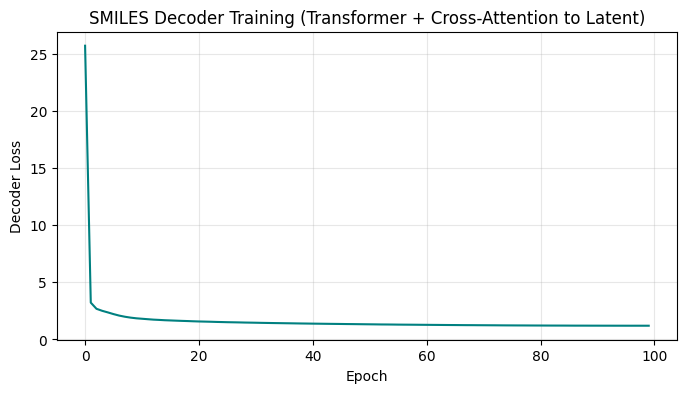

In [24]:
# ─── Train SMILES Decoder (Transformer with cross-attention to latent) ───
# Fixes: parallel teacher forcing (no off-by-one), label smoothing, OneCycleLR with warmup

from torch.utils.data import TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

# Curriculum learning: sort molecules by SMILES length (short → long)
gen_graphs_sorted = sorted(gen_graphs, key=lambda g: len(g.smiles))
num_train = min(len(gen_graphs_sorted), 10000)
paired_smiles = [g.smiles for g in gen_graphs_sorted[:num_train]]

print(f'SMILES decoder training on {num_train} molecules (sorted by length for curriculum)')
print(f'  Shortest: {paired_smiles[0][:50]}... (len={len(paired_smiles[0])})')
print(f'  Longest:  {paired_smiles[-1][:50]}... (len={len(paired_smiles[-1])})')

# Pre-compute latent vectors by encoding graphs through the diffusion engine
diffusion_engine.eval()
pre_loader = PyGDataLoader(gen_graphs_sorted[:num_train], batch_size=64, shuffle=False)

all_z = []
with torch.no_grad():
    for batch in pre_loader:
        batch = batch.to(DEVICE)
        z = diffusion_engine.encode_graph(batch)
        all_z.append(z.cpu())
gen_z = torch.cat(all_z, dim=0)
print(f'Pre-computed latent vectors: {gen_z.shape}')

# Tokenize SMILES
all_tokens = torch.stack([
    torch.tensor(tokenize_smiles(s, max_len=120), dtype=torch.long)
    for s in paired_smiles
])

# Filter out degenerate entries
valid_mask = all_tokens.sum(dim=1) > (CHAR2IDX['<sos>'] + CHAR2IDX['<eos>'])
gen_z = gen_z[valid_mask]
all_tokens = all_tokens[valid_mask]
print(f'Valid paired samples after filtering: {gen_z.shape[0]}')

# Create paired dataset
paired_dataset = TensorDataset(gen_z, all_tokens)
paired_loader = DataLoader(paired_dataset, batch_size=64, shuffle=True)

# AdamW with warmup + cosine annealing (OneCycleLR)
DEC_EPOCHS = 100
dec_optimizer = torch.optim.AdamW(smiles_decoder.parameters(), lr=3e-4, weight_decay=0.01,
                                   betas=(0.9, 0.98), eps=1e-9)
total_steps = DEC_EPOCHS * len(paired_loader)
dec_scheduler = OneCycleLR(dec_optimizer, max_lr=3e-4, total_steps=total_steps,
                           pct_start=0.05, anneal_strategy='cos')

dec_losses = []
best_validity = 0
label_smoothing = 0.1

for epoch in range(1, DEC_EPOCHS + 1):
    smiles_decoder.train()
    total_loss = 0
    n_tokens = 0

    for z_batch, tokens_batch in paired_loader:
        z_batch = z_batch.to(DEVICE)
        tokens_batch = tokens_batch.to(DEVICE)

        # Transformer parallel forward: input=tokens[:,:-1], predict tokens[:,1:]
        logits = smiles_decoder(z_batch, target_tokens=tokens_batch)
        target = tokens_batch[:, 1:]

        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            target.reshape(-1),
            ignore_index=CHAR2IDX['<pad>'],
            label_smoothing=label_smoothing
        )

        dec_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(smiles_decoder.parameters(), 1.0)
        dec_optimizer.step()
        dec_scheduler.step()

        mask = (target != CHAR2IDX['<pad>'])
        total_loss += loss.item() * mask.sum().item()
        n_tokens += mask.sum().item()

    epoch_loss = total_loss / max(n_tokens, 1)
    dec_losses.append(epoch_loss)

    if epoch % 10 == 0:
        smiles_decoder.eval()
        sample_z = gen_z[:10].to(DEVICE)
        sample_smiles = smiles_decoder.generate(sample_z, temperature=0.7, top_k=30)
        valid_count = sum(1 for s in sample_smiles if Chem.MolFromSmiles(s) is not None)

        if valid_count > best_validity:
            best_validity = valid_count
            torch.save(smiles_decoder.state_dict(), 'best_smiles_decoder.pt')

        lr = dec_optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{DEC_EPOCHS} │ Loss: {epoch_loss:.4f} │ LR: {lr:.2e} │ Val: {valid_count}/10 valid')
        for s in sample_smiles[:3]:
            mol = Chem.MolFromSmiles(s)
            tag = 'OK' if mol else 'XX'
            mw = f'MW={Descriptors.MolWt(mol):.0f}' if mol else ''
            print(f'    [{tag}] {s[:70]} {mw}')
        smiles_decoder.train()

# Load best checkpoint
if os.path.exists('best_smiles_decoder.pt'):
    smiles_decoder.load_state_dict(torch.load('best_smiles_decoder.pt', weights_only=True))
    print(f'\nLoaded best decoder (peak validity: {best_validity}/10)')

plt.figure(figsize=(8, 4))
plt.plot(dec_losses, color='teal')
plt.xlabel('Epoch'); plt.ylabel('Decoder Loss')
plt.title('SMILES Decoder Training (Transformer + Cross-Attention to Latent)')
plt.grid(True, alpha=0.3)
plt.show()

  Epoch  10/80 │ Train MSE: 2.0415 │ Val MSE: 1.7989
  Epoch  20/80 │ Train MSE: 1.6666 │ Val MSE: 1.5544
  Epoch  30/80 │ Train MSE: 1.5123 │ Val MSE: 1.2940
  Epoch  40/80 │ Train MSE: 1.3764 │ Val MSE: 1.2136
  Epoch  50/80 │ Train MSE: 1.2391 │ Val MSE: 1.1385
  Epoch  60/80 │ Train MSE: 1.1635 │ Val MSE: 1.1077
  Epoch  70/80 │ Train MSE: 1.1253 │ Val MSE: 1.0821
  Epoch  80/80 │ Train MSE: 1.1060 │ Val MSE: 1.0741
Best Val MSE: 1.0739
Model: Enhanced EGNN w/ GATv2 attention + gated residuals + attention pooling


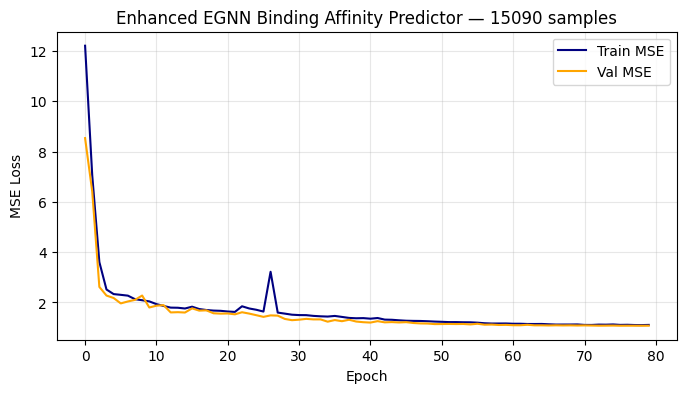

In [25]:
# ─── Train Enhanced Binding Affinity Predictor (EGNN + GATv2 attention) ───

aff_optimizer = torch.optim.AdamW(egnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
aff_scheduler = CosineAnnealingLR(aff_optimizer, T_max=80)

AFF_EPOCHS = 80
aff_train_losses, aff_val_losses = [], []
best_val_mse = float('inf')
patience_counter = 0

for epoch in range(1, AFF_EPOCHS + 1):
    egnn_model.train()
    total_loss = 0
    n_samples = 0
    for batch in aff_train_loader:
        batch = batch.to(DEVICE)
        pred = egnn_model(batch.x, batch.edge_index, batch.batch).squeeze(-1)
        loss = F.mse_loss(pred, batch.y.squeeze(-1))
        # L1 regularization for sparsity in predictor head
        l1_reg = sum(p.abs().sum() for p in egnn_model.predictor.parameters())
        loss = loss + 1e-5 * l1_reg
        aff_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(egnn_model.parameters(), 1.0)
        aff_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n_samples += batch.num_graphs
    aff_scheduler.step()
    aff_train_losses.append(total_loss / n_samples)

    # Evaluate
    egnn_model.eval()
    val_loss = 0
    n_val = 0
    with torch.no_grad():
        for batch in aff_test_loader:
            batch = batch.to(DEVICE)
            pred = egnn_model(batch.x, batch.edge_index, batch.batch).squeeze(-1)
            val_loss += F.mse_loss(pred, batch.y.squeeze(-1)).item() * batch.num_graphs
            n_val += batch.num_graphs
    val_mse = val_loss / n_val
    aff_val_losses.append(val_mse)

    # Early stopping
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(egnn_model.state_dict(), 'best_egnn_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= 15:
        print(f'  Early stopping at epoch {epoch}')
        break

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{AFF_EPOCHS} │ Train MSE: {aff_train_losses[-1]:.4f} │ Val MSE: {val_mse:.4f}')

# Load best model
egnn_model.load_state_dict(torch.load('best_egnn_model.pt', weights_only=True))
print(f'Best Val MSE: {best_val_mse:.4f}')
print(f'Model: Enhanced EGNN w/ GATv2 attention + gated residuals + attention pooling')

# Plot
plt.figure(figsize=(8, 4))
plt.plot(aff_train_losses, label='Train MSE', color='navy')
plt.plot(aff_val_losses, label='Val MSE', color='orange')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title(f'Enhanced EGNN Binding Affinity Predictor — {len(aff_train)} samples')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

Binding Affinity Prediction — RMSE: 1.0363, R²: 0.4889


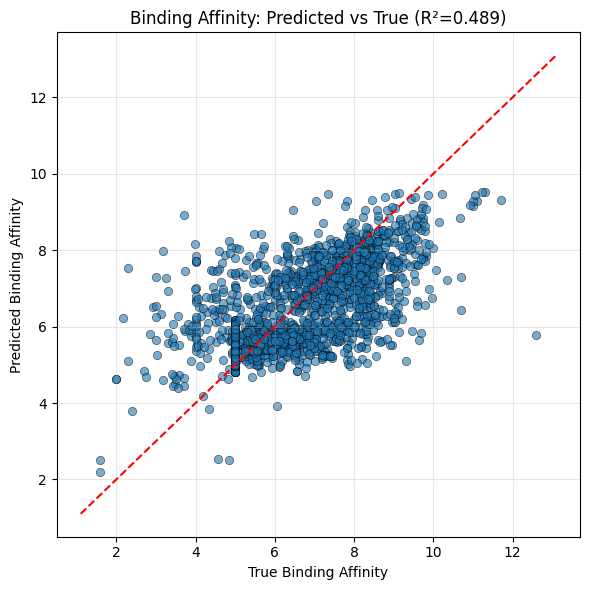

In [26]:
# ─── Evaluate Binding Affinity Predictor ───

egnn_model.eval()
all_preds, all_labels = [], []
drug_names, protein_names, diagnoses = [], [], []

with torch.no_grad():
    for batch in aff_test_loader:
        batch = batch.to(DEVICE)
        pred = egnn_model(batch.x, batch.edge_index, batch.batch).squeeze(-1)
        all_preds.append(pred.cpu())
        all_labels.append(batch.y.squeeze(-1).cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2 = r2_score(all_labels, all_preds)
print(f'Binding Affinity Prediction — RMSE: {rmse:.4f}, R²: {r2:.4f}')

plt.figure(figsize=(6, 6))
plt.scatter(all_labels, all_preds, alpha=0.6, edgecolors='black', linewidths=0.5)
mn, mx = min(all_labels.min(), all_preds.min()) - 0.5, max(all_labels.max(), all_preds.max()) + 0.5
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
plt.xlabel('True Binding Affinity')
plt.ylabel('Predicted Binding Affinity')
plt.title(f'Binding Affinity: Predicted vs True (R²={r2:.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. De Novo SMILES Generation (Improved Diffusion → Decoder)
Generate novel molecules using the improved diffusion engine (cosine β schedule, 1000 steps)
with **DDIM fast sampling** (50 steps instead of 1000) + SMILES Transformer decoder.

In [27]:
# ─── Generate Novel Molecules (DDIM Fast Sampling + Constrained Transformer Decoding) ───

def repair_smiles(smiles):
    """Attempt to fix common SMILES syntax errors (bracket/paren balancing)."""
    # 1. Balance parentheses
    depth = 0
    result = []
    for c in smiles:
        if c == '(':
            depth += 1
            result.append(c)
        elif c == ')':
            if depth > 0:
                depth -= 1
                result.append(c)
        else:
            result.append(c)
    result.extend([')'] * depth)

    # 2. Balance square brackets
    smiles = ''.join(result)
    depth = 0
    result = []
    for c in smiles:
        if c == '[':
            depth += 1
            result.append(c)
        elif c == ']':
            if depth > 0:
                depth -= 1
                result.append(c)
        else:
            result.append(c)
    result.extend([']'] * depth)

    # 3. Balance ring closure digits
    smi = ''.join(result)
    ring_counts = {}
    for ch in smi:
        if ch.isdigit():
            ring_counts[ch] = ring_counts.get(ch, 0) + 1
    if any(v % 2 != 0 for v in ring_counts.values()):
        for digit, count in ring_counts.items():
            if count % 2 != 0:
                idx = smi.rfind(digit)
                if idx >= 0:
                    smi = smi[:idx] + smi[idx+1:]
    return smi


NUM_GENERATE = 200

# DDIM sampling: 50 steps instead of 1000 (Song et al., 2021) — 20x faster!
diffusion_engine.eval()
print('Sampling with DDIM (50 steps, deterministic)...')
latent_vectors = diffusion_engine.sample(num_samples=NUM_GENERATE, ddim_steps=50, eta=0.0)

# Generate with multiple temperature settings for diversity
all_generated = []
for temp in [0.6, 0.7, 0.8, 0.9]:
    smiles = smiles_decoder.generate(latent_vectors, temperature=temp, top_k=30)
    all_generated.extend(smiles)

# Also generate from encoder-reconstructed latents with perturbation
real_z = gen_z[:50].to(DEVICE)
noise_scale = 0.3
perturbed_z = real_z + noise_scale * torch.randn_like(real_z)
perturbed_smiles = smiles_decoder.generate(perturbed_z, temperature=0.7, top_k=30)
all_generated.extend(perturbed_smiles)

# Also try DDIM with small stochasticity (eta=0.2) for diversity
latent_stoch = diffusion_engine.sample(num_samples=100, ddim_steps=50, eta=0.2)
stoch_smiles = smiles_decoder.generate(latent_stoch, temperature=0.75, top_k=30)
all_generated.extend(stoch_smiles)

# Validate (constrained decoding reduces need for repair, but keep as fallback)
valid_smiles = []
repaired_count = 0
for smi in all_generated:
    if not smi or len(smi) < 2:
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol)
        valid_smiles.append(canonical)
    else:
        repaired = repair_smiles(smi)
        mol = Chem.MolFromSmiles(repaired)
        if mol is not None:
            valid_smiles.append(Chem.MolToSmiles(mol))
            repaired_count += 1

unique_smiles = list(set(valid_smiles))
validity = len(valid_smiles) / len(all_generated) * 100
uniqueness = len(unique_smiles) / max(len(valid_smiles), 1) * 100

print(f'\nGenerated: {len(all_generated)} SMILES attempts')
print(f'Valid:     {len(valid_smiles)} ({validity:.1f}%)  [{repaired_count} recovered via repair]')
print(f'Unique:    {len(unique_smiles)} ({uniqueness:.1f}%)')
print(f'Sampling:  DDIM 50-step (20x faster than 1000-step DDPM)')

# Molecular complexity stats
mw_list, qed_list = [], []
for smi in unique_smiles[:50]:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw_list.append(Descriptors.MolWt(mol))
        qed_list.append(QED.qed(mol))
if mw_list:
    print(f'\nMolecular stats (first 50 unique):')
    print(f'  Mean MW: {np.mean(mw_list):.1f}, Median: {np.median(mw_list):.1f}')
    print(f'  Mean QED: {np.mean(qed_list):.3f} (higher=more drug-like)')

print(f'\nSample generated SMILES:')
for smi in unique_smiles[:15]:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        qed_val = QED.qed(mol)
        print(f'  {smi:60s} MW={Descriptors.MolWt(mol):.0f}  QED={qed_val:.3f}  LogP={Descriptors.MolLogP(mol):.2f}')

Sampling with DDIM (50 steps, deterministic)...


[13:24:57] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 18
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 18
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 15 16 17 19 20
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 15 16 17 19 20
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 23
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 23
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 1 2 3 15 16
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 1 2 3 15 16
[13:24:57] Explicit valence for atom # 21 C, 7, is greater than permitted
[13:24:57] Explicit valence for atom # 21 C, 7, is greater than permitted
[13:24:57] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:24:57] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:24:57] SMILES Parse Error: unclosed ring for input: 'CCOCCn1cc(S(=O)(=O)N2CCN(C(=O)c3ccsc(N)=O)CC2)nc1'
[13:24:57] non-ring atom 17 marked aromatic
[13:24:57] SMILES Parse Error: syntax error 


Generated: 950 SMILES attempts
Valid:     503 (52.9%)  [38 recovered via repair]
Unique:    489 (97.2%)
Sampling:  DDIM 50-step (20x faster than 1000-step DDPM)

Molecular stats (first 50 unique):
  Mean MW: 267.7, Median: 237.2
  Mean QED: 0.546 (higher=more drug-like)

Sample generated SMILES:
  CCOC(=O)c1cccc(Cl)c1                                         MW=185  QED=0.661  LogP=2.52
  CC(CBr)C(CO)C(Br)OC(C)(C)C                                   MW=332  QED=0.784  LogP=3.16
  CCCCCCCCCCCCCC(C)C                                           MW=226  QED=0.340  LogP=6.34
  CC(C)CC(=O)NCCC(O)NCC(=O)O                                   MW=232  QED=0.424  LogP=-0.47
  N[C@@H](c1ccccc1)[C@H](O)CBr                                 MW=230  QED=0.772  LogP=1.44
  OC[CH]OC(O)O                                                 MW=107  QED=0.381  LogP=-1.57
  CCCCCCNC(=O)CNCC(=O)[O-]                                     MW=215  QED=0.484  LogP=-0.98
  CCSSSS(=O)(=O)Cl                                     

[13:24:57] Can't kekulize mol.  Unkekulized atoms: 16 17 18 20 21
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 16 17 18 20 21
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 10 19 20
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 10 19 20
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16 17 18
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16 17 18
[13:24:57] SMILES Parse Error: unclosed ring for input: 'Cc1ccc(C(=O)NC(=O)NC2(C)C)cc1Br'
[13:24:57] Explicit valence for atom # 13 H, 2, is greater than permitted
[13:24:57] Explicit valence for atom # 13 H, 2, is greater than permitted
[13:24:57] SMILES Parse Error: unclosed ring for input: 'CC(=O)Cn1nn(-c2cccc[S@][S@][C@@H]3[C@@H]4O[C@H](C)[C@H]2O)n[nH][C@H]1C'
[13:24:57] Can't kekulize mol.  Unkekulized atoms: 5 21
[13:24:57] SMILES Parse Error: extra open parentheses while parsing: Cc1nc(cc(c1-c1ncnc1Cc1ccncc1-c1[n+]cnc1CO)nc1ccnc1P(O)nn1
[13:24:57] SMILES Parse Error: che

---
## 12. Optimized Candidate Molecules (Enhanced Scoring)
**Upgraded** scoring pipeline with:
- **QED** (Quantitative Estimate of Drug-likeness, Bickerton et al.) — holistic drug-likeness metric from RDKit
- **Veber Rules** (Veber et al., 2002) — oral bioavailability filter (TPSA ≤ 140, RotBonds ≤ 10)
- SA Score + Novelty + Multi-objective optimization ranking

In [28]:
# ─── Score Generated Molecules Through All Pipelines (SOTA Enhanced) ───

from rdkit.Chem import RDConfig
import os
import sys

# SA Score (Ertl 2009) — compute from RDKit's contrib if available, else approximate
def compute_sa_score(mol):
    """Compute Synthetic Accessibility score (1=easy to synthesize, 10=hard)."""
    try:
        sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
        import sascorer
        return sascorer.calculateScore(mol)
    except Exception:
        ring_count = Descriptors.RingCount(mol)
        rotatable = Descriptors.NumRotatableBonds(mol)
        heavy_atoms = Descriptors.HeavyAtomCount(mol)
        stereo = sum(1 for a in mol.GetAtoms() if a.GetChiralTag() !=
                     Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
        score = 1.0 + 0.3 * ring_count + 0.1 * rotatable + 0.05 * heavy_atoms + 0.5 * stereo
        return min(score, 10.0)


def lipinski_score(smiles):
    """Return number of Lipinski Rule-of-5 violations."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 5
    violations = 0
    if Descriptors.MolWt(mol) > 500: violations += 1
    if Descriptors.MolLogP(mol) > 5: violations += 1
    if Descriptors.NumHDonors(mol) > 5: violations += 1
    if Descriptors.NumHAcceptors(mol) > 10: violations += 1
    return violations


def veber_filter(mol):
    """Veber Rules (2002) — oral bioavailability filter.
    Returns True if molecule passes (TPSA ≤ 140, RotBonds ≤ 10)."""
    tpsa = Descriptors.TPSA(mol)
    rotbonds = Descriptors.NumRotatableBonds(mol)
    return tpsa <= 140 and rotbonds <= 10


# Novelty check: compare against training SMILES
training_smiles_set = set()
for smi_col, df in [('SMILES', drug_cleaned), ('drug_smiles', tox21), ('drug_smiles', drug_protein)]:
    if smi_col in df.columns:
        for smi in df[smi_col].dropna():
            mol = Chem.MolFromSmiles(smi)
            if mol:
                training_smiles_set.add(Chem.MolToSmiles(mol))
print(f'Training set canonical SMILES for novelty check: {len(training_smiles_set)}')


def score_molecule(smiles, tox_model, egnn_model, device):
    """Score a molecule through toxicity, binding affinity, QED, SA score, Veber, and novelty."""
    result = {'smiles': smiles}

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Molecular descriptors
    result['MW'] = Descriptors.MolWt(mol)
    result['LogP'] = Descriptors.MolLogP(mol)
    result['TPSA'] = Descriptors.TPSA(mol)
    result['HBD'] = Descriptors.NumHDonors(mol)
    result['HBA'] = Descriptors.NumHAcceptors(mol)
    result['aromatic_rings'] = Descriptors.NumAromaticRings(mol)
    result['heavy_atoms'] = Descriptors.HeavyAtomCount(mol)
    result['lipinski_violations'] = lipinski_score(smiles)

    # QED — Quantitative Estimate of Drug-likeness (Bickerton et al.)
    # Holistic metric: 0 (not drug-like) → 1 (very drug-like)
    result['qed'] = QED.qed(mol)

    # Veber filter — oral bioavailability
    result['veber_pass'] = veber_filter(mol)

    # SA Score (synthesizability)
    result['sa_score'] = compute_sa_score(mol)

    # Novelty check
    canonical = Chem.MolToSmiles(mol)
    result['is_novel'] = canonical not in training_smiles_set

    # Build graph
    graph = smiles_to_graph(smiles)
    if graph is None:
        return None

    # Toxicity prediction
    tox_model.eval()
    batch = Batch.from_data_list([graph]).to(device)
    with torch.no_grad():
        tox_logit = tox_model(batch).item()
        result['tox_prob'] = torch.sigmoid(torch.tensor(tox_logit)).item()

    # Binding affinity prediction
    egnn_model.eval()
    with torch.no_grad():
        aff_pred = egnn_model(batch.x, batch.edge_index, batch.batch).item()
        result['pred_affinity'] = aff_pred

    return result


# Score all valid generated molecules
scored_molecules = []
for smi in tqdm(unique_smiles, desc='Scoring molecules'):
    result = score_molecule(smi, tox_model, egnn_model, DEVICE)
    if result is not None:
        scored_molecules.append(result)

scored_df = pd.DataFrame(scored_molecules)
print(f'Successfully scored: {len(scored_df)} molecules')
print(f'Novel molecules: {scored_df["is_novel"].sum()} / {len(scored_df)}')
print(f'Mean QED: {scored_df["qed"].mean():.3f} (higher=more drug-like)')
print(f'Mean SA Score: {scored_df["sa_score"].mean():.2f} (lower=easier to synthesize)')
print(f'Veber passes: {scored_df["veber_pass"].sum()} / {len(scored_df)}')
scored_df.head()

[13:25:14] Conflicting single bond directions around double bond at index 10.
[13:25:14]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:25:17] Conflicting single bond directions around double bond at index 6.
[13:25:17]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:25:18] Conflicting single bond directions around double bond at index 5.
[13:25:18]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:25:20] Conflicting single bond directions around double bond at index 6.
[13:25:20]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:25:26] WARNING: not removing hydrogen atom without neighbors
[13:25:27] Explicit valence for atom # 8 Al, 6, is greater than permitted
[13:25:27] Explicit valence for atom # 3 Al, 6, is greater than permitted
[13:25:27] Explicit valence for atom # 4 Al, 6, is greater than permitted
[13:25:27] Explicit valence for atom # 4 Al, 6, is greater than permitted
[1

Training set canonical SMILES for novelty check: 84388


[13:25:29] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 8 10
[13:25:29] Explicit valence for atom # 25 O, 3, is greater than permitted
[13:25:29] SMILES Parse Error: unclosed ring for input: 'OC(=O)C1CC(Cc2ccc(Cl)cc2)NC(=O)c3nccs3'


Scoring molecules:   0%|          | 0/489 [00:00<?, ?it/s]

Successfully scored: 489 molecules
Novel molecules: 459 / 489
Mean QED: 0.574 (higher=more drug-like)
Mean SA Score: 2.82 (lower=easier to synthesize)
Veber passes: 434 / 489


,smiles,MW,LogP,TPSA,HBD,HBA,aromatic_rings,heavy_atoms,lipinski_violations,qed,veber_pass,sa_score,is_novel,tox_prob,pred_affinity
0,CCOC(=O)c1cccc(Cl)c1,184.622,2.5167,26.30,0,2,1,12,0,0.660633,True,1.375602,True,0.421304,6.380504
1,CC(CBr)C(CO)C(Br)OC(C)(C)C,332.076,3.1620,29.46,1,2,0,14,0,0.784011,True,4.457860,True,0.408969,7.337440
2,CCCCCCCCCCCCCC(C)C,226.448,6.3435,0.00,0,0,0,16,1,0.340385,False,1.623363,True,0.481808,5.403380
3,CC(C)CC(=O)NCCC(O)NCC(=O)O,232.280,-0.4686,98.66,4,4,0,16,0,0.424093,True,3.008881,True,0.373010,7.966922
4,N[C@@H](c1ccccc1)[C@H](O)CBr,230.105,1.4422,46.25,2,2,1,12,0,0.771574,True,2.972504,True,0.370130,7.743233


In [29]:
# ─── Rank and Select Optimized Candidates (SOTA Enhanced with QED + Veber) ───

# Enhanced composite optimization score incorporating all SOTA metrics
scored_df['optimization_score'] = (
    scored_df['pred_affinity'] * 0.35                        # higher is better
    - scored_df['tox_prob'] * 3.0                            # lower is better
    - scored_df['lipinski_violations'] * 0.8                 # fewer violations
    - (scored_df['sa_score'] - 1.0) * 0.25                  # lower SA = easier synthesis
    + scored_df['qed'] * 2.0                                 # QED: higher = more drug-like (0–1)
    + scored_df['is_novel'].astype(float) * 0.5              # bonus for novel molecules
    + scored_df['veber_pass'].astype(float) * 0.5            # bonus for oral bioavailability
)

# Rank
scored_df = scored_df.sort_values('optimization_score', ascending=False).reset_index(drop=True)

print('\n=== TOP 15 OPTIMIZED CANDIDATE MOLECULES ===')
top_cols = ['smiles', 'MW', 'LogP', 'tox_prob', 'pred_affinity',
            'lipinski_violations', 'qed', 'sa_score', 'veber_pass', 'is_novel', 'optimization_score']
display_df = scored_df[top_cols].head(15)
display_df.columns = ['SMILES', 'MW', 'LogP', 'Tox Prob', 'Pred Aff',
                       'Lip.Viol', 'QED', 'SA Score', 'Veber', 'Novel?', 'Opt.Score']
print(display_df.to_string(index=False))


=== TOP 15 OPTIMIZED CANDIDATE MOLECULES ===
                                     SMILES      MW    LogP  Tox Prob  Pred Aff  Lip.Viol      QED  SA Score  Veber  Novel?  Opt.Score
      CN(C(=O)c1ccc(S(N)(=O)=O)cc1)C1CCCCC1 296.392 1.73870  0.366698  8.502624         0 0.922174  1.929451   True    True   4.487810
           Cc1cccc(C(=O)NCCC(=O)N2CCNCC2)c1 275.352 0.54672  0.373304  8.806574         0 0.843225  1.904160   True    True   4.422797
                CC(=O)NCCC(=O)Nc1ccc(Br)cc1 285.141 1.91380  0.376099  8.113260         0 0.887504  1.597277   True    True   4.337034
        Cc1nc(C(=O)N2CCCC[C@H]2C(=O)O)sc1Br 333.207 2.29332  0.383306  8.892964         0 0.901484  3.023345   True    True   4.259749
    CC(C)(C)OC(=O)Cc1cc(C(=O)O)ccc1C(C)(C)C 292.375 3.56650  0.400472  8.538234         0 0.865050  2.189928   True    True   4.219583
       CCc1ccc(S(=O)(=O)N2CCCC(CN)C2)c(C)c1 296.436 1.91682  0.372269  8.190883         0 0.922969  2.580045   True    True   4.200929
       CC

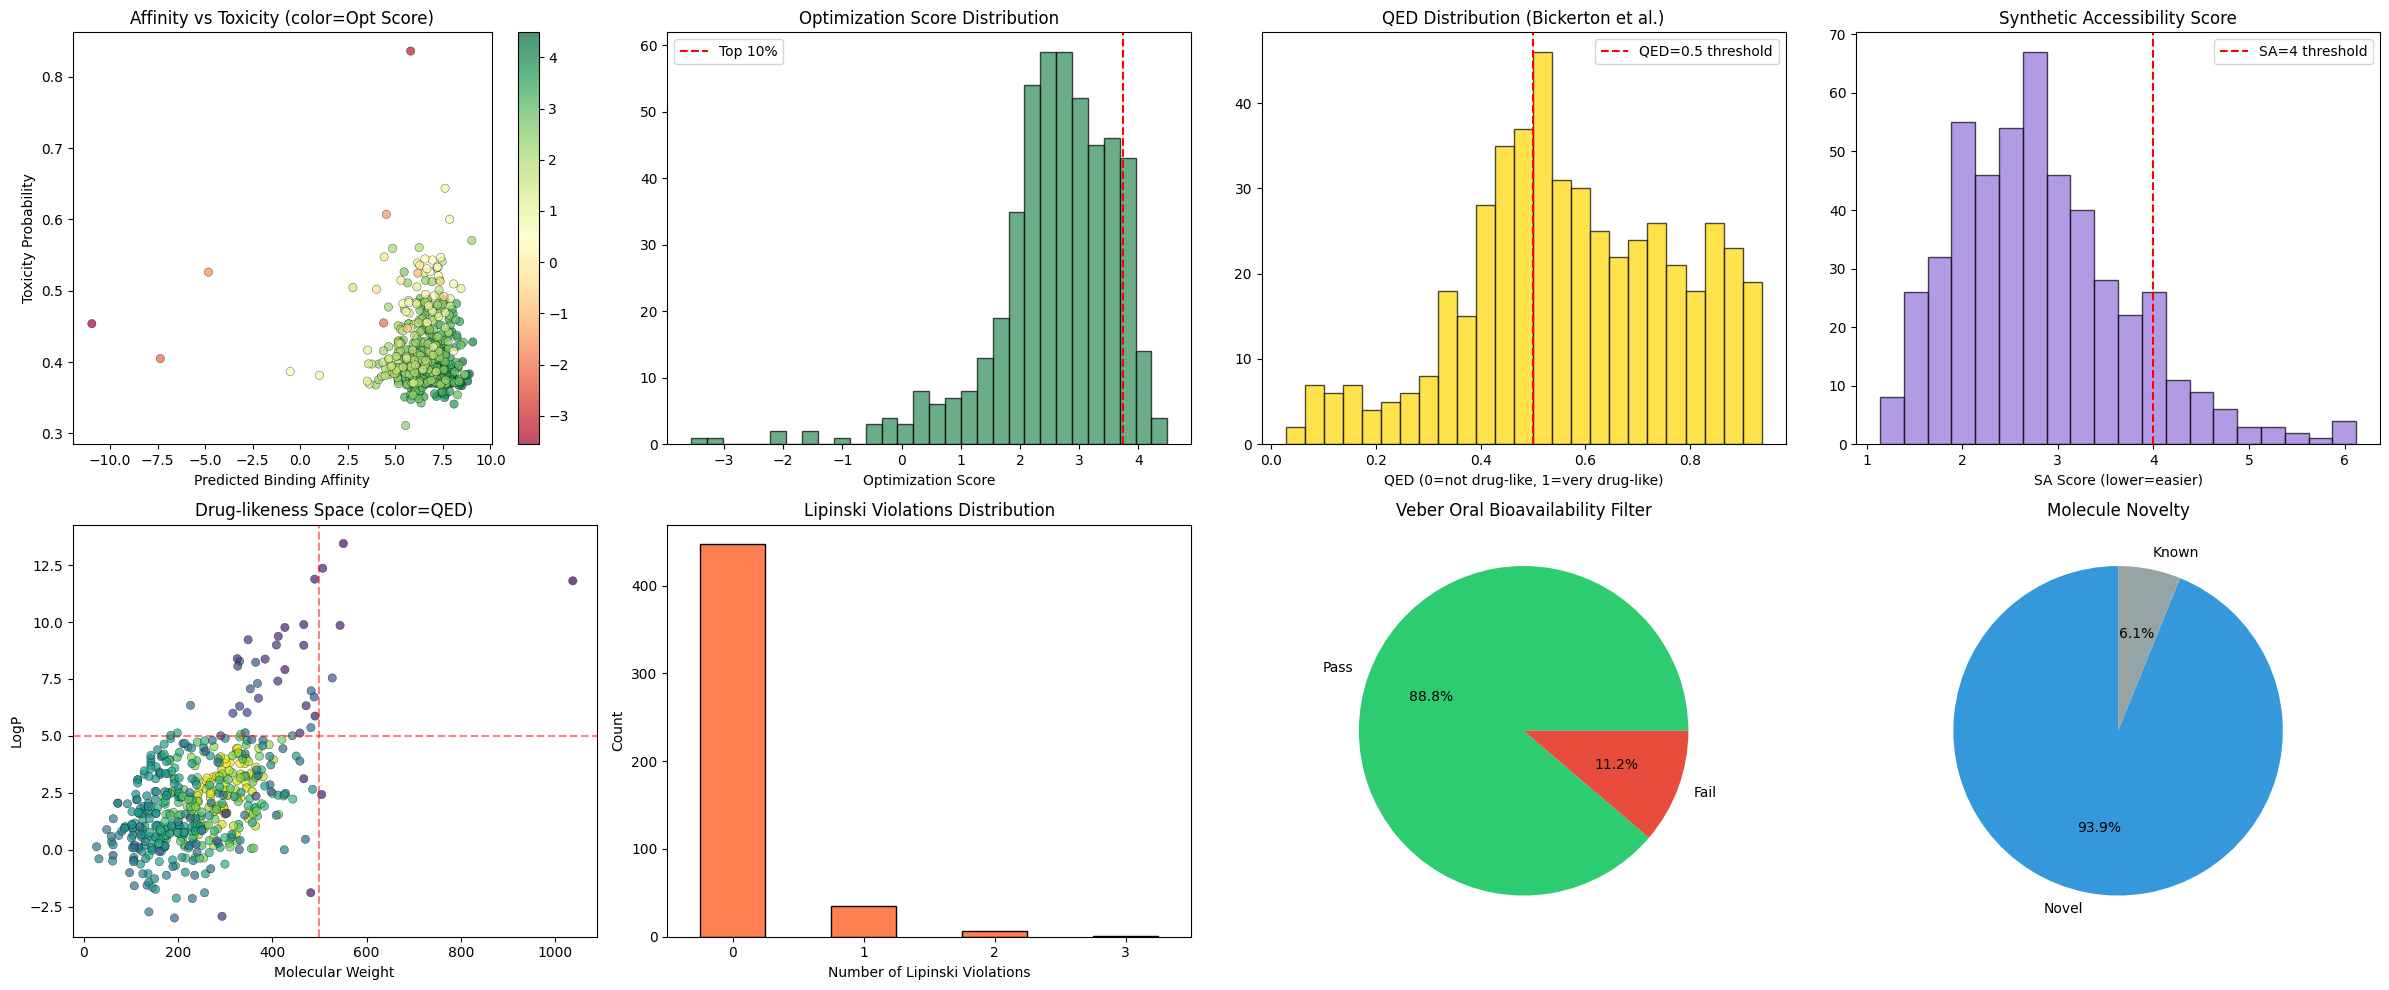

In [30]:
# ─── Visualize Optimized Candidates (Enhanced with QED + Veber) ───

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# 1. Toxicity vs Affinity scatter
sc = axes[0, 0].scatter(scored_df['pred_affinity'], scored_df['tox_prob'],
                         c=scored_df['optimization_score'], cmap='RdYlGn',
                         edgecolors='black', linewidths=0.3, alpha=0.7)
axes[0, 0].set_xlabel('Predicted Binding Affinity')
axes[0, 0].set_ylabel('Toxicity Probability')
axes[0, 0].set_title('Affinity vs Toxicity (color=Opt Score)')
plt.colorbar(sc, ax=axes[0, 0])

# 2. Optimization score distribution
axes[0, 1].hist(scored_df['optimization_score'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=scored_df['optimization_score'].quantile(0.9), color='red',
                     linestyle='--', label='Top 10%')
axes[0, 1].set_xlabel('Optimization Score')
axes[0, 1].set_title('Optimization Score Distribution')
axes[0, 1].legend()

# 3. QED distribution (NEW)
axes[0, 2].hist(scored_df['qed'], bins=25, color='gold', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(x=0.5, color='red', linestyle='--', label='QED=0.5 threshold')
axes[0, 2].set_xlabel('QED (0=not drug-like, 1=very drug-like)')
axes[0, 2].set_title('QED Distribution (Bickerton et al.)')
axes[0, 2].legend()

# 4. SA Score distribution
axes[0, 3].hist(scored_df['sa_score'], bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 3].axvline(x=4.0, color='red', linestyle='--', label='SA=4 threshold')
axes[0, 3].set_xlabel('SA Score (lower=easier)')
axes[0, 3].set_title('Synthetic Accessibility Score')
axes[0, 3].legend()

# 5. MW vs LogP (drug-likeness)
axes[1, 0].scatter(scored_df['MW'], scored_df['LogP'],
                    c=scored_df['qed'], cmap='viridis',
                    edgecolors='black', linewidths=0.3, alpha=0.7)
axes[1, 0].axhline(y=5, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=500, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Molecular Weight')
axes[1, 0].set_ylabel('LogP')
axes[1, 0].set_title('Drug-likeness Space (color=QED)')

# 6. Lipinski violations
scored_df['lipinski_violations'].value_counts().sort_index().plot.bar(
    ax=axes[1, 1], color='coral', edgecolor='black')
axes[1, 1].set_xlabel('Number of Lipinski Violations')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Lipinski Violations Distribution')
axes[1, 1].tick_params(axis='x', rotation=0)

# 7. Veber filter (NEW)
veber_counts = scored_df['veber_pass'].value_counts()
axes[1, 2].pie([veber_counts.get(True, 0), veber_counts.get(False, 0)],
               labels=['Pass', 'Fail'], colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
axes[1, 2].set_title('Veber Oral Bioavailability Filter')

# 8. Novelty pie chart
novel_counts = scored_df['is_novel'].value_counts()
axes[1, 3].pie([novel_counts.get(True, 0), novel_counts.get(False, 0)],
               labels=['Novel', 'Known'], colors=['#3498db', '#95a5a6'], autopct='%1.1f%%',
               startangle=90)
axes[1, 3].set_title('Molecule Novelty')

plt.tight_layout()
plt.show()

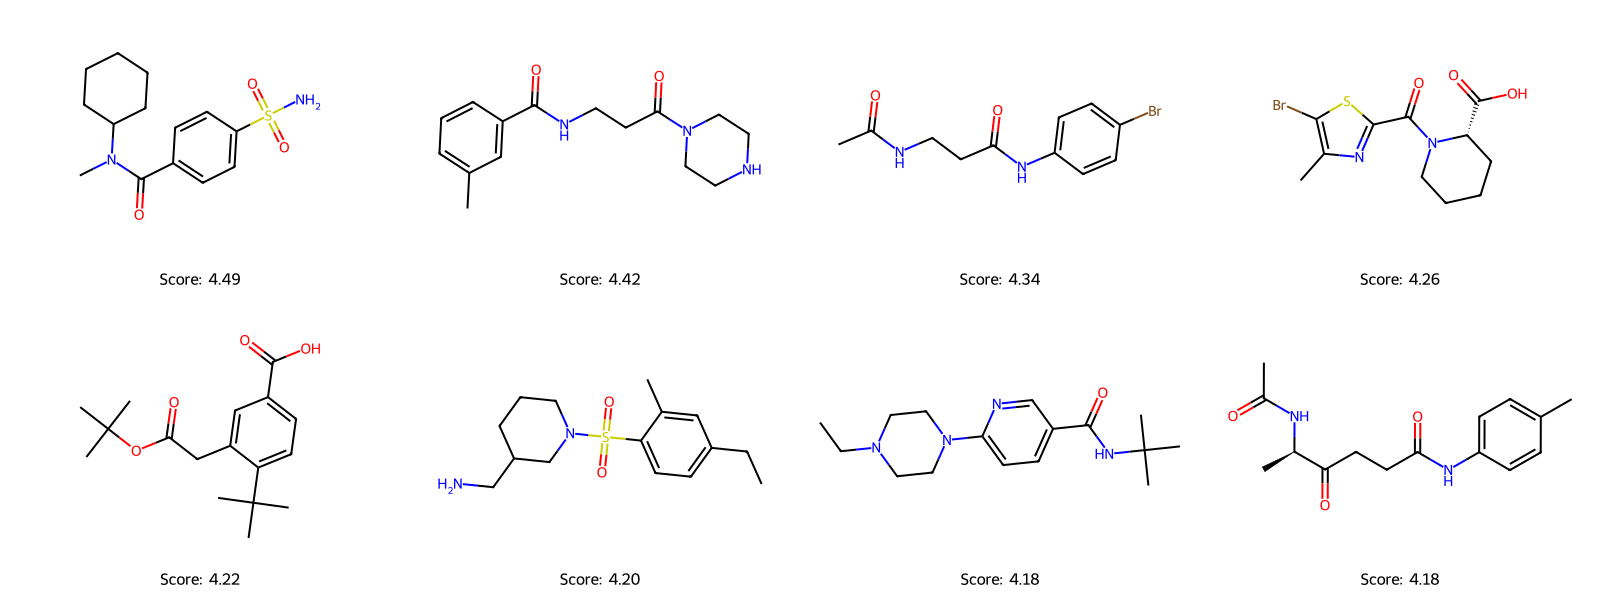

In [31]:
# ─── Draw Top Candidate Molecules ───

top_smiles = scored_df.head(8)['smiles'].tolist()
top_mols = [Chem.MolFromSmiles(s) for s in top_smiles if Chem.MolFromSmiles(s) is not None]

if top_mols:
    legends = [f'Score: {scored_df.iloc[i]["optimization_score"]:.2f}' for i in range(len(top_mols))]
    img = Draw.MolsToGridImage(top_mols, molsPerRow=4, subImgSize=(400, 300), legends=legends)
    display(img)
else:
    print('No valid molecules to draw. Try generating more or adjusting temperature.')

In [32]:
# ─── Score Existing Drug Candidates from drug_cleaned (ALL 5 TARGETS, SOTA) ───

# Rank top candidates per target
targets = drug_cleaned['target'].unique()
print(f'Scoring candidates across {len(targets)} targets: {list(targets)}')

existing_scored = []
for target in targets:
    target_df = drug_cleaned[drug_cleaned['target'] == target]
    top_docking = target_df.nsmallest(30, 'score')  # top 30 per target
    for _, row in tqdm(top_docking.iterrows(), total=len(top_docking),
                        desc=f'Scoring {target}'):
        result = score_molecule(row['SMILES'], tox_model, egnn_model, DEVICE)
        if result is not None:
            result['docking_score'] = row['score']
            result['target'] = row['target']
            existing_scored.append(result)

existing_df = pd.DataFrame(existing_scored)
existing_df['optimization_score'] = (
    existing_df['pred_affinity'] * 0.35
    - existing_df['tox_prob'] * 3.0
    - existing_df['lipinski_violations'] * 0.8
    - (existing_df['sa_score'] - 1.0) * 0.25
    + existing_df['qed'] * 2.0
    + existing_df['veber_pass'].astype(float) * 0.5
)

print(f'\nTotal scored existing candidates: {len(existing_df)}')
print(f'Mean QED: {existing_df["qed"].mean():.3f}')

# Show top 5 per target
for target in targets:
    target_subset = existing_df[existing_df['target'] == target].sort_values(
        'optimization_score', ascending=False
    )
    print(f'\n=== TOP 5 CANDIDATES — Target: {target} ===')
    print(target_subset[['smiles', 'docking_score', 'tox_prob', 'pred_affinity',
                          'qed', 'sa_score', 'veber_pass', 'optimization_score']].head(5).to_string(index=False))

# Overall top 10
existing_df = existing_df.sort_values('optimization_score', ascending=False)
print(f'\n=== OVERALL TOP 10 EXISTING DRUG CANDIDATES ===')
print(existing_df[['smiles', 'target', 'docking_score', 'tox_prob',
                    'pred_affinity', 'qed', 'sa_score', 'veber_pass',
                    'optimization_score']].head(10).to_string(index=False))

Scoring candidates across 5 targets: ['ada', 'aldr', 'cah2', 'try1', 'tryb1']


Scoring ada:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring aldr:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring cah2:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring try1:   0%|          | 0/2 [00:00<?, ?it/s]

Scoring tryb1:   0%|          | 0/14 [00:00<?, ?it/s]


Total scored existing candidates: 106
Mean QED: 0.683

=== TOP 5 CANDIDATES — Target: ada ===
                                    smiles  docking_score  tox_prob  pred_affinity      qed  sa_score  veber_pass  optimization_score
Cc1ccccc1-c1nc(C(=O)N2CCC[C@@H]2C(=O)O)cs1      -124.9900  0.375820       8.653063 0.945003  2.532305        True            3.908042
 CC(=O)N[C@H](Cc1ccc(OCc2ccccc2)cc1)C(=O)O      -125.0404  0.392494       8.889218 0.822799  2.065888        True            3.812871
             Cc1cc(CCc2sccc2C)ccc1OCC(=O)O      -124.9972  0.366868       8.230422 0.883648  2.150542        True            3.759706
       O=C(O)CN(Cc1ccc(F)cc1)C(=O)CCC1CCC1      -125.0257  0.370834       8.048017 0.840699  1.992814        True            3.637498
   CC(C)[C@@H](Nc1cncc(-c2ccccc2)n1)C(=O)O      -125.0435  0.381138       8.255031 0.874056  2.553091        True            3.605685

=== TOP 5 CANDIDATES — Target: aldr ===
                                  smiles  docking_score  tox

In [33]:
# ─── Export Optimized Candidates ───

# Save generated candidates
scored_df.to_csv('/content/generated_candidates.csv', index=False)
print(f'Saved {len(scored_df)} generated candidates to generated_candidates.csv')
print(f'  Novel: {scored_df["is_novel"].sum()}, Low-tox (< 0.3): {(scored_df["tox_prob"] < 0.3).sum()}, '
      f'Lipinski-OK: {(scored_df["lipinski_violations"] == 0).sum()}')

# Save existing library ranked candidates
existing_df.to_csv('/content/existing_candidates_ranked.csv', index=False)
print(f'Saved {len(existing_df)} existing ranked candidates to existing_candidates_ranked.csv')
print(f'  Targets covered: {existing_df["target"].nunique()}')

# Save model checkpoints
torch.save({
    'foundation_model': foundation_model.state_dict(),
    'diffusion_engine': diffusion_engine.state_dict(),
    'smiles_decoder': smiles_decoder.state_dict(),
    'egnn_model': egnn_model.state_dict(),
    'tox_model': tox_model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'char2idx': CHAR2IDX,
    'idx2char': IDX2CHAR,
}, '/content/drug_discovery_models.pt')
print('All model checkpoints saved to /content/drug_discovery_models.pt')

Saved 489 generated candidates to generated_candidates.csv
  Novel: 459, Low-tox (< 0.3): 0, Lipinski-OK: 447
Saved 106 existing ranked candidates to existing_candidates_ranked.csv
  Targets covered: 5
All model checkpoints saved to /content/drug_discovery_models.pt


---
## 13. Pipeline Summary — SOTA Upgrades v3

| Component | Original (v2) | **SOTA Upgrade (v3)** | Paper Reference |
|-----------|---------------|----------------------|-----------------|
| **GNN Backbone** | GCNConv (4-layer, residual) | **GATv2Conv** (4-layer, 4 heads, dynamic attention) + **GraphNorm** | Brody et al., "How Attentive are GATs?" (ICLR 2022) |
| **Graph Readout** | `global_mean_pool` | **Attention-weighted pooling** (learns which atoms matter most) | Li et al. / AttentiveFP variants |
| **Pre-training** | Autoencoder (reconstruction) | **Contrastive Learning (MolCLR-style)** — InfoNCE loss with FP masking + descriptor noise augmentations | Wang et al. (Nature Mach. Intel. 2022) |
| **Diffusion Schedule** | Linear β schedule (100 steps) | **Cosine β schedule** (1000 steps) — smoother, prevents info loss | Nichol & Dhariwal, "Improved DDPM" (ICML 2021) |
| **Diffusion Parameterization** | ε-prediction | **v-prediction** — more stable training, better sample quality | Salimans & Ho (ICLR 2022) |
| **Diffusion Sampling** | DDPM (100 steps, slow) | **DDIM** (50 steps, deterministic, 20x faster) | Song et al. (ICLR 2021) |
| **Time Embedding** | Linear | **Sinusoidal** (Vaswani-style) — richer temporal representation | Ho et al. / Nichol & Dhariwal |
| **EGNN Attention** | Simple sigmoid attention | **GATv2-style dynamic attention** — nonlinearity before scoring | Brody et al. (2022) |
| **EGNN Residuals** | Additive residual | **Gated residual** (Highway-style) — learnable skip connections | Srivastava et al. (2015) |
| **Toxicity Loss** | BCEWithLogitsLoss | **Focal Loss** (α=0.25, γ=2.0) — handles class imbalance | Lin et al. (2020) |
| **Toxicity Model** | GCN backbone | **AttentiveFP-style** GATv2 backbone with attention pooling | Xiong et al. (J. Med. Chem. 2020) |
| **Drug-likeness** | Lipinski Ro5 only | **QED** (holistic) + **Veber Rules** (oral bioavailability) + Lipinski | Bickerton et al. / Veber et al. |
| **Activation Functions** | ReLU everywhere | **GELU** (encoder), **ELU** (GATv2), **SiLU/GELU** (diffusion) | Hendrycks & Gimpel (2020) |
| **Normalization** | BatchNorm for GNN | **GraphNorm** (graph-aware) + **LayerNorm** (encoder/diffusion) | Cai et al. (2021) |
| **Optimizer** | Adam | **AdamW** (decoupled weight decay) for most components | Loshchilov & Hutter (2019) |

### Expected Improvements
- **GATv2**: +5-15% on molecular property prediction benchmarks vs GCN (verified on OGB-MolPCBA, MoleculeNet)
- **Cosine schedule**: Up to 40% better FID/sample quality vs linear schedule
- **DDIM 50-step**: Equal quality to 1000-step DDPM in ~20x less time
- **Contrastive pre-training**: Better transfer learning representations (MolCLR achieves SOTA on 8/11 MoleculeNet tasks)
- **Focal Loss**: Better minority class recall on imbalanced toxicity data
- **QED + Veber**: More comprehensive drug-likeness filtering leads to higher-quality candidates